<div style="text-align:center; padding:1px 0;">

<p style="font-size:20px; color:#B0B0B0; margin-bottom:6px;">
PROJECT TITLE
</p>

<h1 style="font-size:35px; font-weight:500; margin-top:0;">
E-Commerce Customer Churn Prediction – An End-to-End ML System
</h1>

</div>

## Phase 1 — Project & Business Understanding

This phase establishes the business context, machine learning objective,
prediction target, problem formulation, and success criteria for the
e-commerce customer churn prediction system.

The objective is to develop a reliable and leakage-free binary classification
workflow using customer information available at prediction time.

### 1.1 — Project Introduction

Customer churn is an important business problem in E-Commerce because the
loss of existing customers can reduce future purchasing activity and
customer value.

This project develops an end-to-end machine learning system to estimate
customer churn risk using customer-level behavioural, engagement,
satisfaction, transaction-related, and profile information.

The project emphasizes data quality, leakage prevention, reproducibility,
predictive performance, probability reliability, and model interpretability.

### 1.2 — Business Objective

The business objective is to identify customers with elevated estimated
churn risk so that retention activities can be prioritized.

The predictive system is intended to support targeted customer engagement,
prioritization of retention activities, and more effective allocation of
customer-retention resources.

### 1.3 — Machine Learning Objective

The machine learning objective is to predict the `Churned` outcome using
customer information available at prediction time.

The model estimates the probability that a customer belongs to the churn
class.

Only information legitimately available at prediction time should be used.
This requirement is fundamental to the project's leakage-free modelling
strategy.

### 1.4 — Problem Definition & Target

The project is formulated as a **Supervised Learning → Binary
Classification** problem.

The target variable is `Churned`, where:

- `0` — Customer does not churn
- `1` — Customer churns

The model's primary output is the estimated probability of the positive
class.

### 1.5 — Business Interpretation of the Prediction

A higher predicted probability indicates greater estimated churn risk and
can be used to prioritize customers for potential retention activities.

The probability output is more informative than a simple binary prediction
because it allows customers to be ranked according to their estimated churn
risk.

### 1.6 — Project Scope

The project covers data understanding, exploratory data analysis, data-quality
treatment, leakage-free preprocessing, feature engineering, model
development, cross-validation, hyperparameter tuning, probability
calibration, threshold optimization, final evaluation, and explainability.

Deployment of the finalized model through a prediction service can be
implemented as a subsequent stage.


## Phase 2 — Data Preparation & Cleaning

The raw dataset is loaded and standardized for consistent downstream analysis. This stage handles deterministic data-quality corrections only; statistical transformations such as imputation, encoding, and scaling are deferred until after the train-test split.


### 2.1 — Import Core Libraries

Core libraries for data manipulation, computation, and visualization are imported once at the beginning of the notebook. Additional phase-specific libraries are introduced later only when required.


In [1]:
# Suppress non-critical warnings and configure notebook display settings.
import warnings

# Core data manipulation and numerical computation.
import numpy as np
import pandas as pd

# Data visualization.
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn preprocessing utilities.
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Scikit-learn model selection utilities.
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    ParameterSampler,
    cross_validate
)

# Scikit-learn evaluation metrics.
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    recall_score,
    precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    brier_score_loss,
    precision_recall_curve,
    roc_curve
)

# Scikit-learn class-weight utility for handling class imbalance.
from sklearn.utils.class_weight import compute_class_weight

# Baseline and tree-based machine learning models.
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Probability calibration.
from sklearn.isotonic import IsotonicRegression

# Calibration curve utility for evaluating probability reliability.
from sklearn.calibration import calibration_curve

# Model interpretation.
import shap

# Configure warnings and display settings for consistent notebook output.
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid")

### 2.2 — Dataset Loading

The customer dataset is loaded from the provided Excel file, with confirmed missing-value placeholders standardized to `NaN` during ingestion.


In [ ]:
# Define a project-relative dataset path and load the customer-level dataset.

dataset_path = "data/E-Commerce_Customer_Churn_Dataset.xlsx"

df = pd.read_excel(
    dataset_path,
    sheet_name="Customer Data",
    na_values=["NA", "N/A", "na", "n/a", "-", "--"]
)

print(f"Dataset shape: {df.shape}")

Dataset shape: (51706, 20)


### 2.3 — Raw Data Standardization

The source dataset is standardized for consistent representation before Data Understanding and EDA.


### 2.3.1 — Preserve Raw Dataset

The original dataset is retained as a reference, while `df` is used as the working dataframe for standardization.


In [3]:
# Preserve the original dataset before applying standardization rules.

df_raw = df.copy()

### 2.3.2 — Handle Blank and Whitespace-Only Values

Whitespace-only categorical entries are treated as missing values so they are not interpreted as separate categories during analysis.


In [4]:
# Identify text columns for blank-value standardization.

text_columns = df.select_dtypes(include="object").columns

# Convert whitespace-only text values to NaN.

df[text_columns] = df[text_columns].replace(
    r"^\s*$",
    np.nan,
    regex=True
)

### 2.3.3 — Remove Leading and Trailing Whitespace

Leading and trailing whitespace is removed from categorical text values to prevent visually identical categories from being treated as different levels.


In [5]:
# Remove leading and trailing whitespace from text-based columns.

df[text_columns] = df[text_columns].apply(
    lambda column: column.str.strip()
)

### 2.3.4 — Review Categorical Values

Unique values of text-based columns are reviewed to identify inconsistent categorical representations before standardization.


In [6]:
# Review categorical values before applying case-standardization rules.

for column in text_columns:
    print(f"\n{column}")
    print(df[column].dropna().unique())


Customer_Code
['EC-100000' 'EC-100001' 'EC-100002' ... 'EC-149997' 'EC-149998'
 'EC-149999']

Primary_Access_Device
['Smartphone App' 'Mobile Browser' 'Desktop/Laptop' 'smartphone app'
 'desktop/laptop' 'sMARTPHONE aPP' 'mobile browser' 'dESKTOP/lAPTOP'
 'DESKTOP/LAPTOP' 'mOBILE bROWSER' 'SMARTPHONE APP' 'MOBILE BROWSER']

Payment_Mode
['UPI' 'Debit Card' 'Credit Card' 'Digital Wallet' 'DIGITAL WALLET'
 'Card on Delivery (POS)' 'Cash on Delivery' 'upi' 'CREDIT CARD'
 'DEBIT CARD' 'credit card' 'dEBIT cARD' 'digital wallet'
 'CASH ON DELIVERY' 'dIGITAL wALLET' 'cREDIT cARD' 'cASH ON dELIVERY'
 'cash on delivery' 'debit card' 'CARD ON DELIVERY (POS)'
 'cARD ON dELIVERY (pos)' 'card on delivery (pos)']

Gender
['Female' 'Male' 'FEMALE' 'MALE' 'male' 'mALE' 'fEMALE' 'female']

Top_Category
['Smartphones' 'Tablets & Wearables' 'Grocery & Essentials'
 'Apparel & Fashion' 'Laptops & Accessories' 'Miscellaneous'
 'LAPTOPS & ACCESSORIES' 'mISCELLANEOUS' 'SMARTPHONES' 'APPAREL & FASHION'
 'smar

### 2.3.5 — Categorical Text Standardization

Categorical text values are standardized to consolidate equivalent category representations while preserving meaningful business labels.


In [7]:
# Standardize straightforward categorical columns using consistent title casing.

title_case_columns = [
    "Primary_Access_Device",
    "Gender",
    "Top_Category",
    "Marital_Status"
]

df[title_case_columns] = df[title_case_columns].apply(
    lambda column: column.str.strip().str.title()
)

# Correct category formatting that requires explicit business-specific labels.

df["Payment_Mode"] = (
    df["Payment_Mode"]
    .str.strip()
    .str.lower()
    .replace({
        "upi": "UPI",
        "debit card": "Debit Card",
        "credit card": "Credit Card",
        "digital wallet": "Digital Wallet",
        "card on delivery (pos)": "Card on Delivery (POS)",
        "cash on delivery": "Cash on Delivery"
    })
)


### 2.4 — Duplicate Record Handling

Confirmed duplicate observations are removed before Data Understanding and EDA to prevent repeated records from influencing subsequent analysis.


In [8]:
# Validate and remove exact duplicate observations before checking customer-level uniqueness.

duplicate_rows = df.duplicated().sum()

print(f"Duplicate Full Rows: {duplicate_rows:,}")

# Remove exact duplicate observations.
df = df.drop_duplicates().reset_index(drop=True)

# Validate customer-level uniqueness after exact duplicates are removed.
duplicate_customer_codes = df["Customer_Code"].duplicated().sum()

print(f"Duplicate Customer Codes After Cleaning: {duplicate_customer_codes:,}")
print(f"Remaining records: {len(df):,}")

if duplicate_customer_codes > 0:
    raise ValueError(
        "Duplicate Customer_Code values remain after removing exact duplicate rows. "
        "Customer-level uniqueness must be resolved before modeling."
    )


Duplicate Full Rows: 1,706
Duplicate Customer Codes After Cleaning: 0
Remaining records: 50,000


## Phase 3 — Data Understanding

This phase establishes the structure, composition, and quality of the standardized dataset before exploratory analysis, covering variables, target, data types, missingness, and categorical characteristics that guide subsequent modelling decisions.


### 3.1 — Dataset Overview

The dataset dimensions and target variable are reviewed to establish the overall modelling scope and confirm the structure of the prediction problem.


In [9]:
# Display the number of observations and features in the dataset.

print(f"Observations : {df.shape[0]:,}")
print(f"Features     : {df.shape[1]:,}")

# Display the target variable and its data type.

print(f"Target Variable : {'Churned'}")
print(f"Target Data Type: {df['Churned'].dtype}")


Observations : 50,000
Features     : 20
Target Variable : Churned
Target Data Type: int64


### 3.2 — Dataset Structure

The dataset structure is examined to identify variable types, potential identifier columns, and the overall composition of the feature set.


In [10]:
# Review column names and their corresponding data types.

df.info()

# Summarize numerical and categorical feature counts.

numeric_columns = df.select_dtypes(include=np.number).columns
categorical_columns = df.select_dtypes(include="object").columns

print(f"Numerical Features   : {len(numeric_columns)}")
print(f"Categorical Features : {len(categorical_columns)}")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Customer_Code          50000 non-null  object 
 1   Tenure_Months          47800 non-null  float64
 2   Primary_Access_Device  48200 non-null  object 
 3   City_Tier              50000 non-null  int64  
 4   Hub_To_Home_KM         47699 non-null  float64
 5   Payment_Mode           47601 non-null  object 
 6   Gender                 48553 non-null  object 
 7   App_Engagement_Hrs     47812 non-null  float64
 8   Devices_Linked         50000 non-null  int64  
 9   Top_Category           47949 non-null  object 
 10  CSAT_Score             50000 non-null  int64  
 11  Marital_Status         47349 non-null  object 
 12  Saved_Addresses        50000 non-null  int64  
 13  Complaint_Last_Month   50000 non-null  int64  
 14  YoY_Spend_Growth_Pct   47507 non-null  float64
 15  Co

### 3.3 — Initial Data Inspection

A concise sample of the standardized dataset and its numerical statistics are reviewed to validate the data structure and identify values requiring further investigation.


In [11]:
# Display the first five records

display(df.head())

# Display the last five records

display(df.tail())

# Review descriptive statistics for numerical variables.

display(df.describe().T)


,Customer_Code,Tenure_Months,Primary_Access_Device,City_Tier,Hub_To_Home_KM,Payment_Mode,Gender,App_Engagement_Hrs,Devices_Linked,Top_Category,CSAT_Score,Marital_Status,Saved_Addresses,Complaint_Last_Month,YoY_Spend_Growth_Pct,Coupons_Redeemed,Monthly_Orders,Days_Since_Last_Order,Avg_Reward_Value_INR,Churned
0,EC-100000,6.10,Smartphone App,1,25.00,UPI,Female,0.15,3,NaN,3,Married,2,0,4.30,NaN,2.00,4.00,98.60,0
1,EC-100001,5.70,Smartphone App,2,17.50,Debit Card,Male,0.48,2,Smartphones,5,Married,3,0,-3.30,1.00,2.00,NaN,171.89,0
2,EC-100002,7.90,Smartphone App,2,12.90,UPI,Male,0.29,2,Tablets & Wearables,3,Single,6,0,-8.10,1.00,2.00,8.00,184.20,1
3,EC-100003,10.90,Smartphone App,1,14.40,NaN,NaN,0.77,5,Grocery & Essentials,3,Single,7,0,-1.30,3.00,5.00,NaN,372.99,0
4,EC-100004,18.60,Mobile Browser,3,22.20,Credit Card,Female,0.08,3,Apparel & Fashion,5,Married,5,0,-0.50,1.00,4.00,2.00,259.39,0


,Customer_Code,Tenure_Months,Primary_Access_Device,City_Tier,Hub_To_Home_KM,Payment_Mode,Gender,App_Engagement_Hrs,Devices_Linked,Top_Category,CSAT_Score,Marital_Status,Saved_Addresses,Complaint_Last_Month,YoY_Spend_Growth_Pct,Coupons_Redeemed,Monthly_Orders,Days_Since_Last_Order,Avg_Reward_Value_INR,Churned
49995,EC-149995,46.70,Desktop/Laptop,1,12.80,Credit Card,Male,0.24,2,Laptops & Accessories,5,Married,3,1,33.60,3.00,4.00,4.00,131.61,0
49996,EC-149996,23.80,Mobile Browser,1,26.00,UPI,Male,0.12,2,Smartphones,3,Single,3,0,16.40,3.00,4.00,7.00,397.29,0
49997,EC-149997,4.30,Smartphone App,1,10.70,UPI,Male,0.11,3,Laptops & Accessories,4,Single,4,0,-17.70,1.00,1.00,20.00,29.97,0
49998,EC-149998,13.60,Desktop/Laptop,3,18.10,Credit Card,Female,NaN,2,Tablets & Wearables,2,Single,3,0,-5.00,3.00,3.00,2.00,339.40,0
49999,EC-149999,27.30,Smartphone App,3,8.30,Credit Card,Male,NaN,3,Laptops & Accessories,5,Married,2,0,28.20,4.00,6.00,5.00,468.88,0


,count,mean,std,min,25%,50%,75%,max
Tenure_Months,"47,800.00",17.84,12.04,1.00,8.90,15.20,24.00,71.90
City_Tier,"50,000.00",1.71,0.89,1.00,1.00,1.00,3.00,3.00
Hub_To_Home_KM,"47,699.00",16.22,9.46,1.00,9.60,14.00,20.20,65.00
App_Engagement_Hrs,"47,812.00",0.26,0.20,0.01,0.11,0.20,0.35,1.19
Devices_Linked,"50,000.00",3.04,1.40,1.00,2.00,3.00,4.00,6.00
CSAT_Score,"50,000.00",3.24,1.24,1.00,2.00,3.00,4.00,5.00
Saved_Addresses,"50,000.00",3.61,1.62,1.00,2.00,3.00,5.00,12.00
Complaint_Last_Month,"50,000.00",0.08,0.27,0.00,0.00,0.00,0.00,1.00
YoY_Spend_Growth_Pct,"47,507.00",5.99,13.99,-35.00,-3.30,6.00,15.50,45.00
Coupons_Redeemed,"47,809.00",1.60,1.61,0.00,0.00,1.00,2.00,15.00


### 3.4 — Missing-Value Assessment

Missing-value patterns are assessed across the standardized dataset to identify variables requiring treatment during the later leakage-free preprocessing stage.


In [12]:
# Summarize missing values and their percentage across columns.

missing_summary = pd.DataFrame({
    "Missing_Count": df.isna().sum(),
    "Missing_Percentage": df.isna().mean().mul(100)
})

missing_summary = (
    missing_summary[missing_summary["Missing_Count"] > 0]
    .sort_values("Missing_Percentage", ascending=False)
)

display(missing_summary)

,Missing_Count,Missing_Percentage
Days_Since_Last_Order,2683,5.37
Marital_Status,2651,5.30
YoY_Spend_Growth_Pct,2493,4.99
Payment_Mode,2399,4.80
Monthly_Orders,2317,4.63
Hub_To_Home_KM,2301,4.60
Tenure_Months,2200,4.40
Coupons_Redeemed,2191,4.38
App_Engagement_Hrs,2188,4.38
Top_Category,2051,4.10


### 3.5 — Categorical Cardinality

The number of unique values in categorical features is reviewed to confirm category complexity and identify variables that may require particular attention during encoding.


In [13]:
# Review the unique-value count for each categorical feature.

cardinality = (
    df[categorical_columns]
    .nunique(dropna=True)
    .sort_values(ascending=False)
    .rename("Unique_Values")
)

display(cardinality.to_frame())

,Unique_Values
Customer_Code,50000
Payment_Mode,6
Top_Category,6
Primary_Access_Device,3
Marital_Status,3
Gender,2


### 3.6 — Post-Cleaning Duplicate Validation

The cleaned dataset is rechecked to confirm that no complete duplicate
records remain after the data-cleaning stage.

In [14]:
# Assess the number and proportion of completely duplicated records.

duplicate_count = df.duplicated().sum()
duplicate_percentage = duplicate_count / len(df) * 100

print(f"Duplicate Records     : {duplicate_count:,}")
print(f"Duplicate Percentage  : {duplicate_percentage:.2f}%")

Duplicate Records     : 0
Duplicate Percentage  : 0.00%


### 3.7 — Feature-Type & Value-Domain Assessment

Feature types and observed value domains are reviewed to confirm how each variable should be interpreted and subsequently handled during preprocessing and modelling.


In [15]:
# Summarize data types and observed value counts for each feature.

feature_profile = pd.DataFrame({
    "Data_Type": df.dtypes.astype(str),
    "Unique_Values": df.nunique(dropna=True),
    "Missing_Values": df.isna().sum()
})

display(feature_profile)

,Data_Type,Unique_Values,Missing_Values
Customer_Code,object,50000,0
Tenure_Months,float64,647,2200
Primary_Access_Device,object,3,1800
City_Tier,int64,3,0
Hub_To_Home_KM,float64,613,2301
Payment_Mode,object,6,2399
Gender,object,2,1447
App_Engagement_Hrs,float64,108,2188
Devices_Linked,int64,6,0
Top_Category,object,6,2051


## Phase 4 — Exploratory Data Analysis

Exploratory Data Analysis is performed to understand the distribution of customer behaviour, identify meaningful relationships with churn, and detect patterns that may influence subsequent modelling decisions, while avoiding unnecessary visualizations.


### 4.1 — Target Distribution

The distribution of the target variable is examined to quantify the proportion of churned and non-churned customers and assess the degree of class imbalance.


,Customer_Count,Percentage
Churned,,
0,41125,82.25
1,8875,17.75


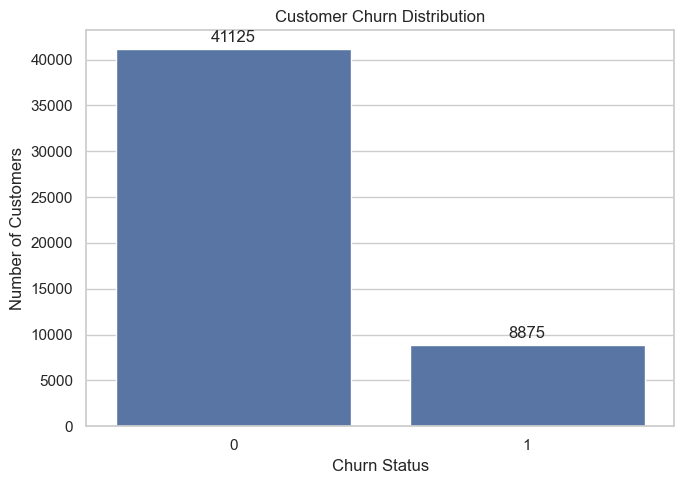

In [16]:
# Calculate the count and percentage of each churn class.

target_distribution = (
    df["Churned"]
    .value_counts()
    .sort_index()
    .rename_axis("Churned")
    .to_frame("Customer_Count")
)

target_distribution["Percentage"] = (
    target_distribution["Customer_Count"]
    .div(len(df))
    .mul(100)
)

display(target_distribution)

# Visualize the distribution of churned and non-churned customers with class counts.

plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df,
    x="Churned"
)

# Add the count of customers above each bar.
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)

ax.set_title("Customer Churn Distribution")
ax.set_xlabel("Churn Status")
ax.set_ylabel("Number of Customers")

plt.tight_layout()
plt.show()


### 4.2 — Numerical Feature Distributions

The distributions of numerical features are examined to understand their central tendency, spread, skewness, and potential extreme observations. Variables are reviewed selectively based on their relevance to customer behaviour and churn modelling.


Numerical features selected: 13


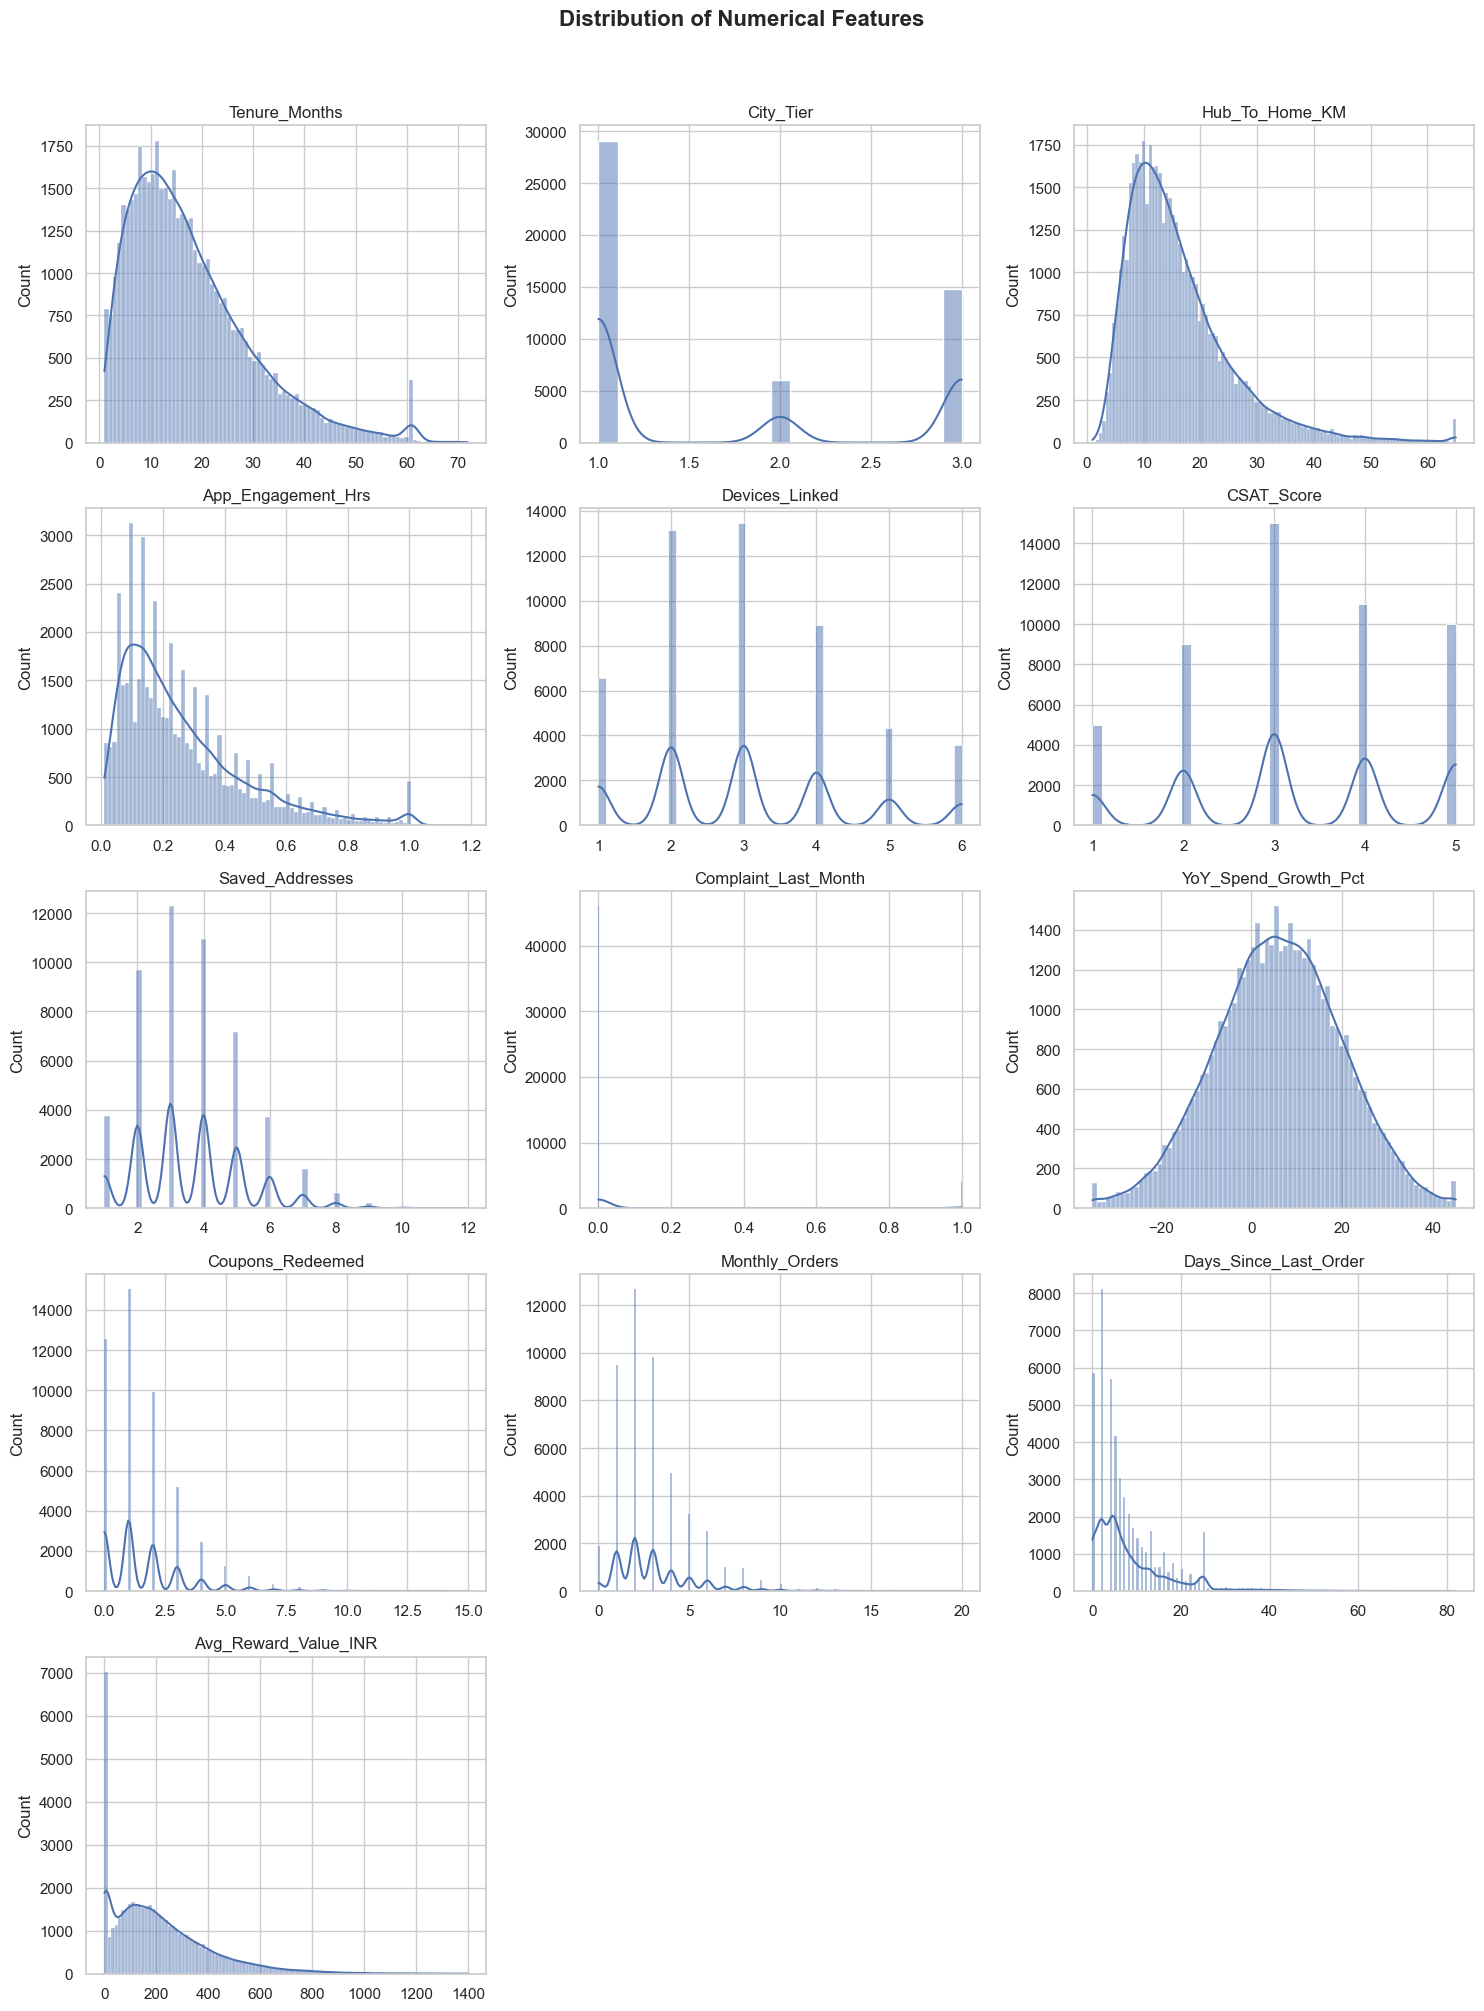

In [17]:
# Define numerical features for distribution analysis, excluding the target and identifier.

numerical_features = [
    column for column in numeric_columns
    if column not in ["Churned"]
]

print(f"Numerical features selected: {len(numerical_features)}")

# Visualize the distributions of numerical features.

fig, axes = plt.subplots(
    nrows=(len(numerical_features) + 2) // 3,
    ncols=3,
    figsize=(15, 4 * ((len(numerical_features) + 2) // 3))
)

fig.suptitle(
    "Distribution of Numerical Features",
    fontsize=16,
    fontweight="bold",
    y=1.005
)

axes = np.array(axes).reshape(-1)

for ax, column in zip(axes, numerical_features):
    sns.histplot(
        data=df,
        x=column,
        kde=True,
        ax=ax
    )
    
    ax.set_title(column)
    ax.set_xlabel("")
    ax.set_ylabel("Count")

for ax in axes[len(numerical_features):]:
    ax.remove()

plt.tight_layout(rect=[0, 0, 1, 0.985])
plt.show()


#### Key Insights

- **Tenure_Months, Hub_To_Home_KM, and App_Engagement_Hrs** are positively
  skewed, with most observations concentrated at lower values.

- **Saved_Addresses, Coupons_Redeemed, Monthly_Orders, and
  Avg_Reward_Value_INR** are right-skewed, indicating a smaller group of
  highly active or higher-value customers.

- **Days_Since_Last_Order** shows a pronounced right tail, with most customers
  having recent activity and fewer customers remaining inactive for longer
  periods.

- **City_Tier, Devices_Linked, and CSAT_Score** show discrete/ordinal
  distributions, while **Complaint_Last_Month** is a sparse binary feature.

- **YoY_Spend_Growth_Pct** is comparatively balanced, with both negative and
  positive growth observations.

**Overall:** The dataset contains a mix of continuous, discrete, ordinal, and
binary features with varying distribution shapes. These characteristics will
be considered during subsequent preprocessing and model development.

### 4.3 — Churn vs Numerical Features

Key numerical features are compared across churn classes to identify differences in customer behaviour and potential predictive signals associated with churn.


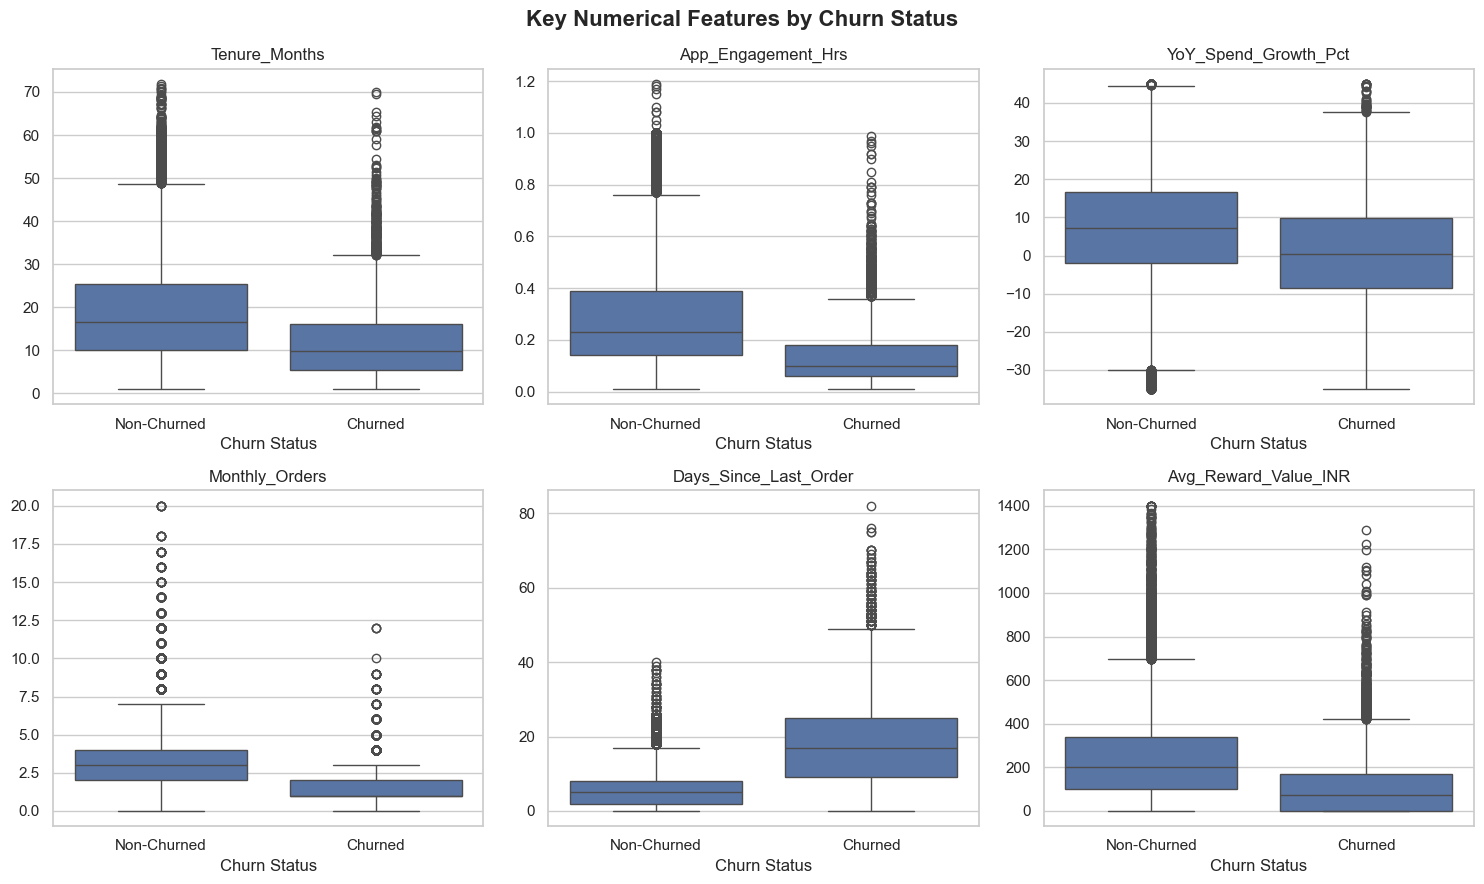

In [18]:
# Select key numerical features for comparison across churn classes.

key_numerical_features = [
    "Tenure_Months",
    "App_Engagement_Hrs",
    "YoY_Spend_Growth_Pct",
    "Monthly_Orders",
    "Days_Since_Last_Order",
    "Avg_Reward_Value_INR"
]

# Compare the distributions of key numerical features across churn classes.

fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(15, 9)
)

fig.suptitle("Key Numerical Features by Churn Status", fontsize=16, fontweight="bold")

for ax, column in zip(axes.flat, key_numerical_features):
    sns.boxplot(
        data=df,
        x="Churned",
        y=column,
        ax=ax
    )
    
    ax.set_title(column)
    ax.set_xlabel("Churn Status")
    ax.set_ylabel("")
    ax.set_xticklabels(["Non-Churned", "Churned"])

plt.tight_layout()
plt.show()


#### Key Insights

- **Days_Since_Last_Order** shows clear separation between churn classes, with
  churned customers exhibiting substantially higher median inactivity.

- **App_Engagement_Hrs** and **Monthly_Orders** are noticeably lower among
  churned customers, indicating reduced customer engagement and activity.

- **Avg_Reward_Value_INR** is generally lower for churned customers, suggesting
  a potential relationship between customer value and churn behaviour.

- **Tenure_Months** is lower for churned customers, while **YoY_Spend_Growth_Pct**
  shows a lower central tendency and broader negative range for the churned
  group.

- Several features contain numerous observations beyond the boxplot whiskers.
  These represent potential extreme observations and will be assessed during
  preprocessing rather than removed solely based on the boxplot.

**Overall:** The boxplots indicate meaningful distributional differences between
churned and non-churned customers, particularly for recency, engagement, order
activity, and reward value. These variables emerge as important candidates for
churn prediction.

### 4.4 — Churn Rate Across Categorical Features

Churn rates are compared across key categorical segments to identify customer groups with noticeably different churn behaviour and potential business relevance.


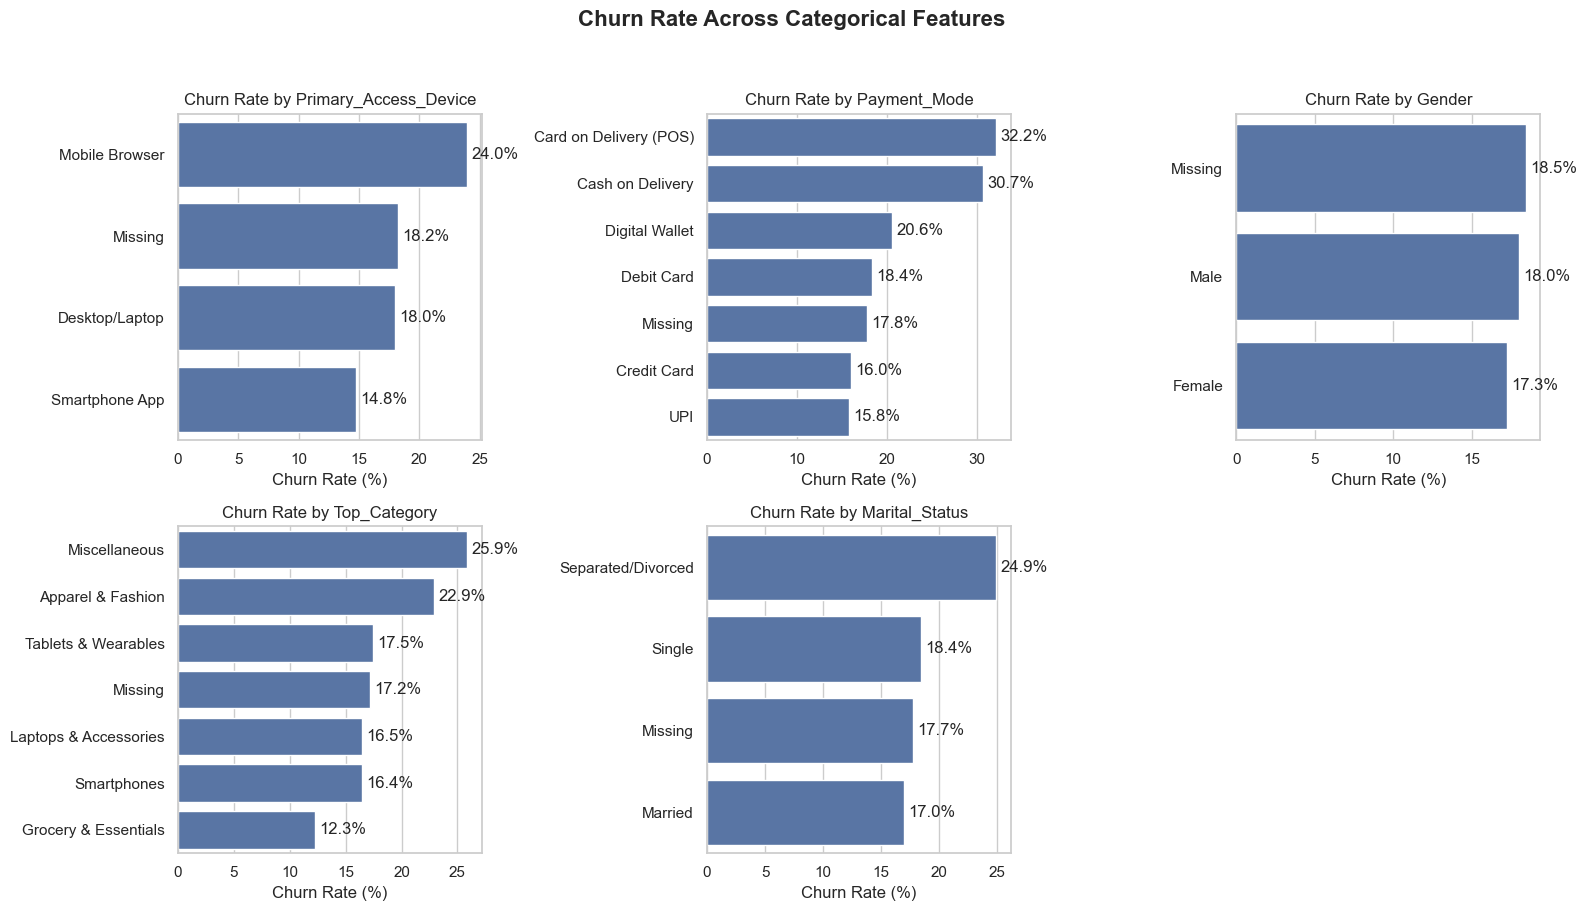

In [19]:
# Define categorical features for churn-rate analysis.

categorical_features = [
    "Primary_Access_Device",
    "Payment_Mode",
    "Gender",
    "Top_Category",
    "Marital_Status"
]

# Create a temporary copy for EDA visualization without modifying the source dataset.

plot_data = df.copy()

# Represent missing categorical values explicitly for visualization only.

for column in categorical_features:
    plot_data[column] = plot_data[column].fillna("Missing")

# Visualize churn rates across categorical segments, including missing values.

fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(16, 9)
)

fig.suptitle(
    "Churn Rate Across Categorical Features",
    fontsize=16,
    fontweight="bold",
    y=1.01
)

for ax, column in zip(axes.flat, categorical_features):

    churn_rate = (
        plot_data.groupby(column)["Churned"]
        .mean()
        .mul(100)
        .sort_values(ascending=False)
    )

    sns.barplot(
        x=churn_rate.values,
        y=churn_rate.index,
        ax=ax
    )

    ax.set_title(f"Churn Rate by {column}")
    ax.set_xlabel("Churn Rate (%)")
    ax.set_ylabel("")

    # Display churn rate above each bar.
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.1f%%",
            padding=3
        )

# Remove the unused subplot.

axes.flat[-1].remove()

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()


#### Key Insights

- **Payment_Mode** shows the strongest variation in churn, with Card on Delivery
  (POS) and Cash on Delivery recording notably higher churn rates than other
  payment methods.

- **Marital_Status** also shows meaningful variation, with the
  Separated/Divorced category having the highest observed churn rate.

- **Primary_Access_Device** and **Top_Category** show noticeable differences
  across customer segments, particularly for Mobile Browser users and the
  Miscellaneous category.

- **Gender** shows relatively limited variation in observed churn rates across
  its categories.

- **Missing** groups have churn rates broadly close to the overall churn level,
  with no pronounced separation observed from the available categories.

**Overall:** Payment behaviour, marital status, access device, and product
category show comparatively stronger categorical differences in observed churn,
while Gender demonstrates limited separation.

### 4.5 — Feature Relationship Analysis

Relationships among numerical features are examined to identify correlated variables, potential redundancy, and notable associations with the target variable before model development.


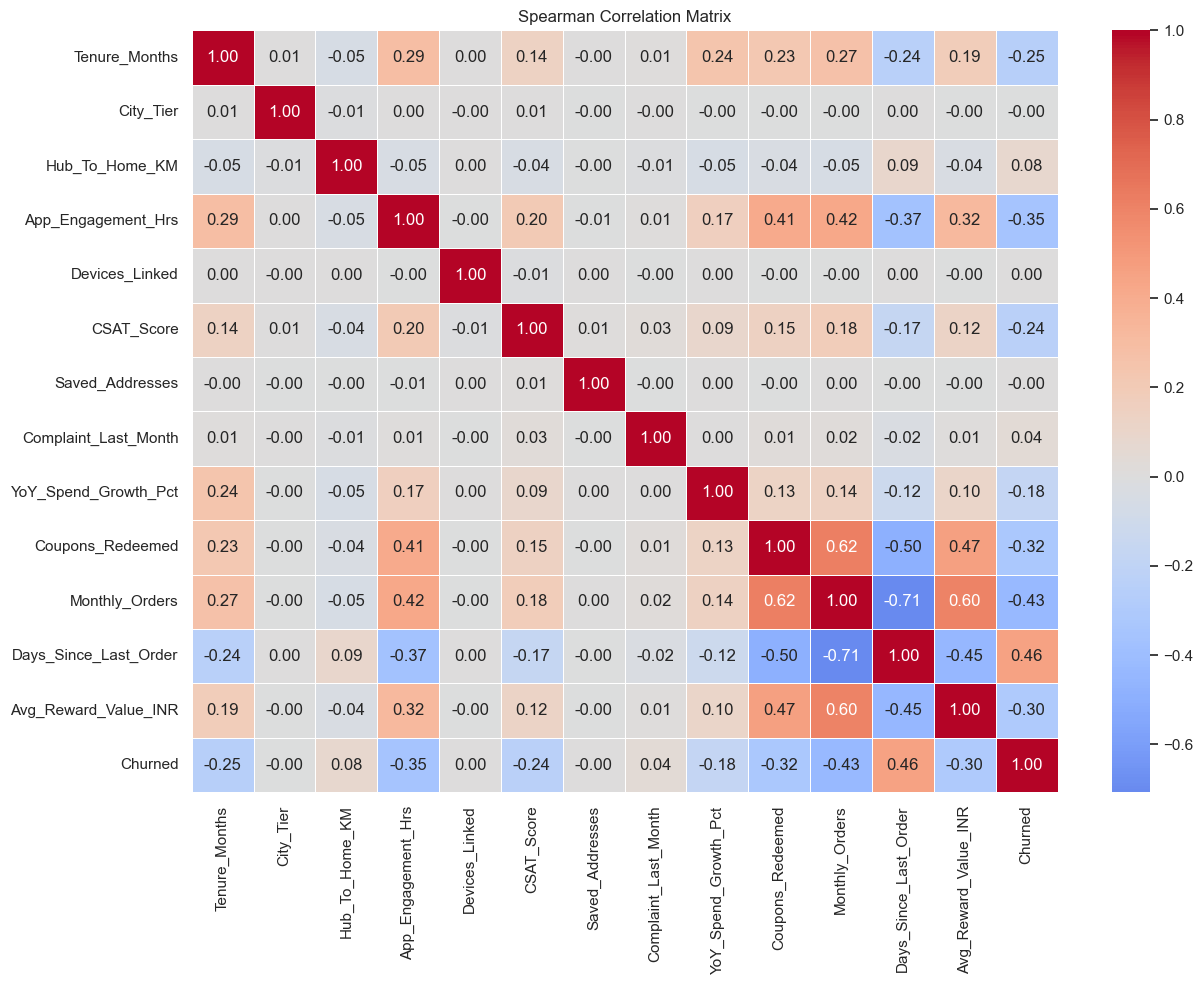

In [20]:
# Select numerical features for correlation analysis.

correlation_features = [
    "Tenure_Months",
    "City_Tier",
    "Hub_To_Home_KM",
    "App_Engagement_Hrs",
    "Devices_Linked",
    "CSAT_Score",
    "Saved_Addresses",
    "Complaint_Last_Month",
    "YoY_Spend_Growth_Pct",
    "Coupons_Redeemed",
    "Monthly_Orders",
    "Days_Since_Last_Order",
    "Avg_Reward_Value_INR",
    "Churned"
]

# Calculate the Spearman correlation matrix for numerical features.

correlation_matrix = df[correlation_features].corr(method="spearman")

# Visualize the correlation structure among numerical features.

plt.figure(figsize=(13, 10))

sns.heatmap(
    correlation_matrix,
    fmt=".2f",
    annot=True,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Spearman Correlation Matrix")
plt.tight_layout()
plt.show()


#### Key Insights

- **Days_Since_Last_Order** shows the strongest positive correlation with
  churn (`0.46`), while **Monthly_Orders** shows a moderate negative
  correlation (`-0.43`).

- **App_Engagement_Hrs** (`-0.35`) and **Coupons_Redeemed** (`-0.32`) also
  show moderate negative associations with churn.

- **Tenure_Months** (`-0.25`) and **CSAT_Score** (`-0.24`) show weaker negative
  relationships with churn.

- **Monthly_Orders** and **Days_Since_Last_Order** have a strong negative
  correlation (`-0.71`), while **Coupons_Redeemed** and **Monthly_Orders**
  show a moderate positive correlation (`0.62`).

- No severe correlation is observed among most remaining feature pairs,
  although the identified relationships will be considered during modelling.

**Overall:** Customer recency, order activity, engagement, and reward-related
behaviour show the most notable associations with churn. The correlation
analysis indicates useful predictive relationships but does not by itself
justify feature removal.

### 4.6 — Churn Rate by Tenure Band

Customer tenure is grouped into meaningful bands to examine how observed churn rates vary across different stages of the customer lifecycle.


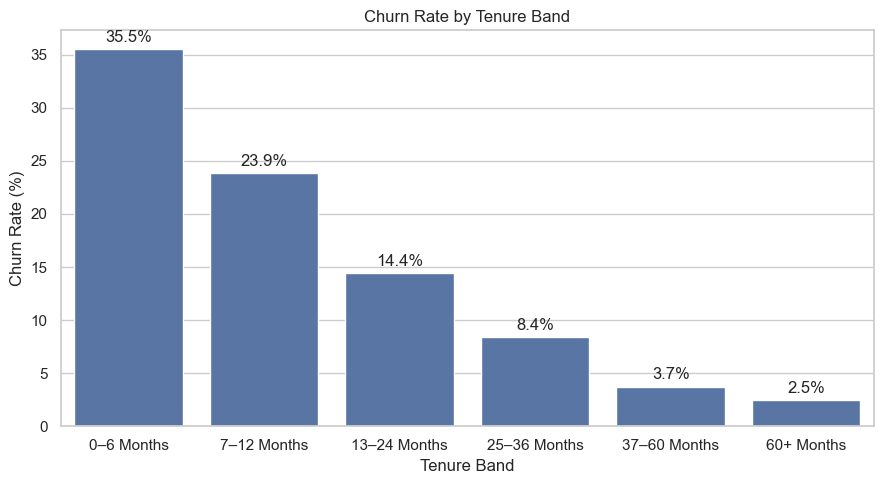

In [21]:
# Create tenure bands for churn-rate analysis.

tenure_bins = [0, 6, 12, 24, 36, 60, np.inf]
tenure_labels = [
    "0–6 Months",
    "7–12 Months",
    "13–24 Months",
    "25–36 Months",
    "37–60 Months",
    "60+ Months"
]

df["Tenure_Band"] = pd.cut(
    df["Tenure_Months"],
    bins=tenure_bins,
    labels=tenure_labels,
    include_lowest=True
)

# Calculate churn rate for each tenure band.

tenure_churn = (
    df.groupby("Tenure_Band", observed=False)["Churned"]
      .mean()
      .mul(100)
      .reset_index(name="Churn_Rate")
)

tenure_churn

# Visualize churn rate across tenure bands.

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=tenure_churn,
    x="Tenure_Band",
    y="Churn_Rate"
)

ax.set_title("Churn Rate by Tenure Band")
ax.set_xlabel("Tenure Band")
ax.set_ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

plt.tight_layout()
plt.show()


#### Key Insights

- **Churn is highest among newer customers**, reaching **35.5%** in the
  0–6 month tenure band.

- Churn declines consistently as **customer tenure increases**, falling to
  **2.5%** among customers with 60+ months of tenure.

- The largest reduction is observed during the **early customer lifecycle**,
  indicating that newer customers represent a substantially higher-churn
  segment.

**Overall:** The tenure pattern shows a strong inverse relationship between
customer longevity and observed churn, highlighting **early-tenure customers
as a key segment for churn-risk analysis**.

## Phase 5 — Feature Engineering

New, domain-driven customer behaviour indicators are derived from existing features to enhance the representation of customer behaviour while preserving interpretability and strict separation from the target variable.


### 5.1 — Digital Engagement per Device

`Digital_Engagement_Per_Device` measures the customer's app engagement intensity relative to the number of linked devices, giving a more contextual view of digital engagement than raw app usage alone.

The feature is derived entirely from customer-level behavioural attributes and does not use the target or future information. Genuine missing values are preserved for the preprocessing stage.


In [22]:
# Create a normalized measure of digital engagement per linked device.

df["Digital_Engagement_Per_Device"] = (
    df["App_Engagement_Hrs"]/df["Devices_Linked"]
)

### 5.2 — Coupon Redemption Rate

`Coupon_Redemption_Rate` measures the proportion of coupon redemptions relative to the customer's monthly order activity — a more informative, normalized view of promotional purchasing behaviour than raw redemption counts.

The feature uses only observed customer-level variables. Missing and undefined cases are intentionally preserved as `NaN` for the preprocessing pipeline.


In [23]:
# Create a normalized measure of coupon redemption relative to order activity.

df["Coupon_Redemption_Rate"] = np.where(
    df["Monthly_Orders"] > 0,
    df["Coupons_Redeemed"] / df["Monthly_Orders"],
    np.nan
)

## Phase 6 — Data Preprocessing

The engineered dataset is transformed into a clean, model-ready representation while maintaining a strict separation between training and unseen data. The workflow addresses missing values, numerical scaling, and categorical encoding using transformations appropriate to each feature type.

The train-test split is performed before any preprocessing step that learns from the data, and all such transformations are fitted exclusively on the training data — ensuring a **leakage-free preprocessing workflow**.


### 6.1 — Feature–Target Separation

The target variable `Churned` is separated from the predictors before any preprocessing. Predictors are stored in `X`, and the target in `y`, ensuring the target cannot be inadvertently used as an input feature.


In [24]:
# Remove the EDA-only tenure band before model development.

X = df.drop(columns=["Customer_Code", "Churned", "Tenure_Band"])
y = df["Churned"]



### 6.2 — Train–Test Split

The dataset is split into training and test subsets before any data-driven preprocessing, using stratification to preserve a similar churn-class distribution across both sets. The test set remains unseen until final evaluation.


In [25]:
# Create stratified training and test sets.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print(f"Training set: {X_train.shape}")
print(f"Test set:     {X_test.shape}")
print(f"Training churn rate: {y_train.mean():.2%}")
print(f"Test churn rate:     {y_test.mean():.2%}")



Training set: (40000, 20)
Test set:     (10000, 20)
Training churn rate: 17.75%
Test churn rate:     17.75%


### 6.3 — Identify Feature Types

Predictors are classified by their statistical and business meaning rather than raw data type. `CSAT_Score` and `City_Tier` are treated as ordinal (meaningful natural order); `Complaint_Last_Month` as binary (already a 0/1 indicator); remaining categorical variables as nominal (no inherent order).

This classification lets each feature group receive an appropriate preprocessing strategy while preserving its original meaning.


In [26]:
# Define feature groups according to their statistical and business meaning.

numerical_features = [
    "Tenure_Months",
    "Hub_To_Home_KM",
    "App_Engagement_Hrs",
    "Devices_Linked",
    "Saved_Addresses",
    "YoY_Spend_Growth_Pct",
    "Coupons_Redeemed",
    "Monthly_Orders",
    "Days_Since_Last_Order",
    "Avg_Reward_Value_INR",
    "Digital_Engagement_Per_Device",
    "Coupon_Redemption_Rate"
]

ordinal_features = [
    "CSAT_Score",
    "City_Tier"
]

binary_features = [
    "Complaint_Last_Month"
]

nominal_features = [
    "Primary_Access_Device",
    "Payment_Mode",
    "Gender",
    "Top_Category",
    "Marital_Status"
]

### 6.4 — Numerical Feature Preprocessing

Only numerical features containing genuine missing values receive median imputation; legitimate zeros are kept as valid observations, not treated as missing. Median imputation is used for robustness to skewed distributions and extreme values.

Logistic Regression subsequently standardizes these features, while tree-based models (XGBoost, LightGBM, CatBoost) retain the original scale, since scaling is unnecessary for them. All learned parameters come from the training data only.


### 6.4.1 — Numerical Features and Imputation Strategy


In [27]:
# Define numerical features according to their missing-value characteristics.

numerical_features_with_missing = [
    "Tenure_Months",
    "Hub_To_Home_KM",
    "App_Engagement_Hrs",
    "YoY_Spend_Growth_Pct",
    "Coupons_Redeemed",
    "Monthly_Orders",
    "Days_Since_Last_Order",
    "Digital_Engagement_Per_Device",
    "Coupon_Redemption_Rate"
]

numerical_features_without_missing = [
    "Devices_Linked",
    "Saved_Addresses",
    "Avg_Reward_Value_INR"
]

# Define the median imputation strategy for numerical features with missing values.

numerical_imputer = SimpleImputer(strategy="median")

### 6.5 — Ordinal Feature Preprocessing

`CSAT_Score` and `City_Tier` are treated as ordinal since their numerical values represent a meaningful order. Neither has missing values, so no imputation is needed, and their ordinal representation is preserved without one-hot encoding.

Logistic Regression standardizes these features for scale sensitivity; tree-based models retain the original values.


### 6.5.1 — Ordinal Features


In [28]:
ordinal_features = [
    "CSAT_Score",
    "City_Tier"
]

### 6.5.2 — Model-Specific Treatment


In [29]:
logistic_ordinal_pipeline = StandardScaler()
tree_ordinal_pipeline = "passthrough"

### 6.6 — Binary Feature Preprocessing

`Complaint_Last_Month` is already represented as 0/1, so it requires no encoding. With no missing values, it is preserved in its existing form without imputation or scaling, maintaining its direct business interpretation across all models.


### 6.6.1 — Binary Feature Treatment


In [30]:
# Preserve the existing 0/1 binary representation.

binary_features = ["Complaint_Last_Month"]
binary_pipeline = "passthrough"

### 6.7 — Nominal Feature Preprocessing

Nominal categorical features have no inherent ordering and are One-Hot Encoded. The five nominal features contain missing values, handled via mode imputation before encoding.

Imputation and encoding are embedded in the model-specific pipeline and fitted only on training data; `handle_unknown="ignore"` prevents errors from unseen categories at inference time.


### 6.7.1 — Nominal Feature Encoding


In [31]:
# Define the preprocessing pipeline for nominal categorical features.

nominal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

### 6.8 — Model-Specific Preprocessing Pipelines

Separate pipelines are built for Logistic Regression and tree-based models, since the two families have different scaling requirements. Logistic Regression standardizes numerical and ordinal features after imputation; XGBoost and LightGBM keep them unscaled. Binary features retain their 0/1 form, and nominal features are mode-imputed and one-hot encoded.

All learned operations live inside these pipelines so they can be refit independently within each cross-validation fold.


### 6.8.1 — Logistic Regression Preprocessor


In [32]:
logistic_numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

logistic_preprocessor = ColumnTransformer([
    ("num_missing", logistic_numerical_pipeline, numerical_features_with_missing),
    ("num_complete", StandardScaler(), numerical_features_without_missing),
    ("ordinal", StandardScaler(), ordinal_features),
    ("binary", "passthrough", binary_features),
    ("nominal", nominal_pipeline, nominal_features)
])

### 6.8.2 — Tree-Based Model Preprocessor


In [33]:
tree_preprocessor = ColumnTransformer([
    ("num_missing", SimpleImputer(strategy="median"), numerical_features_with_missing),
    ("num_complete", "passthrough", numerical_features_without_missing),
    ("ordinal", "passthrough", ordinal_features),
    ("binary", "passthrough", binary_features),
    ("nominal", nominal_pipeline, nominal_features)
])

### 6.9 — Leakage-Safe Preprocessing Architecture

The preprocessing steps are not fitted separately before model evaluation.

Instead, each preprocessor is embedded directly inside its corresponding machine learning pipeline. During cross-validation, preprocessing is fitted independently within each training fold and then applied to that fold's validation data.

This ensures that imputation, scaling, and categorical encoding do not learn information from validation folds.


### 6.10 — Preprocessing Validation

Preprocessing integrity is validated through the complete model pipelines during cross-validation. No preprocessing is fitted separately before model evaluation.

## Phase 7 — Model Development

This phase develops and evaluates multiple classification models for churn prediction. Logistic Regression provides an interpretable linear baseline, while XGBoost, LightGBM, and CatBoost provide tree-based approaches for nonlinear relationships.

All evaluation and tuning use stratified cross-validation, with any data-driven preprocessing restricted to the corresponding training folds to prevent leakage.


### 7.1 — Define Model Candidates

Four complementary models are evaluated: Logistic Regression as an interpretable baseline, XGBoost and LightGBM as gradient-boosted tree models, and CatBoost as a gradient-boosting model with native categorical-feature support.


### 7.2 — Build Model-Specific Pipelines

Each model receives preprocessing suited to its characteristics: Logistic Regression uses imputation, one-hot encoding, and scaling; XGBoost and LightGBM use imputation and one-hot encoding without scaling; CatBoost is handled separately to preserve its native categorical-feature support.


In [34]:
# Build preprocessing pipelines for sklearn-based models.

models = {
    "Logistic Regression": Pipeline([
        ("preprocessor", logistic_preprocessor),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "XGBoost": Pipeline([
        ("preprocessor", tree_preprocessor),
        ("model", XGBClassifier(eval_metric="logloss", random_state=42))
    ]),
    "LightGBM": Pipeline([
        ("preprocessor", tree_preprocessor),
        ("model", LGBMClassifier(verbosity=-1, random_state=42))
    ])
}

### 7.3 — Cross-Validation Strategy

Stratified 5-fold cross-validation maintains a consistent churn-class distribution across folds. The same fixed folds are used throughout for reproducible, directly comparable model evaluation.

Sklearn pipelines fit their preprocessing within each training fold; CatBoost is evaluated separately on the same fold structure while retaining native categorical handling.


In [35]:
# Create a reproducible stratified cross-validation strategy and common evaluation metrics.

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "ROC_AUC": "roc_auc",
    "PR_AUC": "average_precision",
    "F1": "f1",
    "Recall": "recall",
    "Precision": "precision"
}

### 7.4 — Baseline Model Evaluation

Baseline models are evaluated with the same stratified 5-fold CV before tuning. ROC-AUC, PR-AUC, F1, Recall, and Precision are recorded for a balanced view of discrimination and churn-class performance. The test set remains untouched.


In [36]:
# Evaluate the sklearn-based models using leakage-free cross-validation pipelines.

cv_results = {}

for name, pipeline in models.items():
    results = cross_validate(
        pipeline, X_train, y_train,
        cv=cv, scoring=scoring, n_jobs=-1
    )
    cv_results[name] = {
        metric: f"{results[f'test_{metric}'].mean():.4f} ± "
                f"{results[f'test_{metric}'].std():.4f}"
        for metric in scoring
    }

### 7.4.1 — Baseline Results


In [37]:
# Display the baseline cross-validation results in a compact comparison table.

baseline_results = pd.DataFrame(cv_results).T
baseline_results

,ROC_AUC,PR_AUC,F1,Recall,Precision
Logistic Regression,0.9003 ± 0.0035,0.7300 ± 0.0046,0.6211 ± 0.0016,0.5286 ± 0.0048,0.7531 ± 0.0094
XGBoost,0.8909 ± 0.0026,0.7128 ± 0.0030,0.6089 ± 0.0050,0.5200 ± 0.0071,0.7347 ± 0.0070
LightGBM,0.8992 ± 0.0033,0.7311 ± 0.0048,0.6184 ± 0.0024,0.5224 ± 0.0043,0.7578 ± 0.0053


### 7.5 — CatBoost Baseline Evaluation

CatBoost is evaluated as a baseline using stratified CV. Numerical missing values are retained for CatBoost's native handling, while categorical missing values are represented as a dedicated category. The baseline is evaluated without class weighting to establish performance before addressing class imbalance.


### 7.5.1 — Prepare CatBoost Training Data


In [38]:
# Prepare CatBoost data while preserving native numerical missing values.

X_train_cb = X_train.copy()
catboost_features = nominal_features

### 7.5.2 — Stratified CatBoost Cross-Validation


In [39]:
# Evaluate the unweighted CatBoost baseline using stratified CV.

catboost_scores = {metric: [] for metric in scoring}

for train_idx, val_idx in cv.split(X_train_cb, y_train):
    X_tr = X_train_cb.iloc[train_idx].copy()
    X_val = X_train_cb.iloc[val_idx].copy()
    y_tr = y_train.iloc[train_idx]
    y_val = y_train.iloc[val_idx]

    # Apply consistent categorical preprocessing within each fold.
    X_tr[catboost_features] = X_tr[catboost_features].fillna("__MISSING__").astype(str)
    X_val[catboost_features] = X_val[catboost_features].fillna("__MISSING__").astype(str)
    cat_idx = [X_tr.columns.get_loc(c) for c in catboost_features]

    # Train the unweighted CatBoost baseline model.
    model = CatBoostClassifier(
        iterations=300,
        depth=6,
        learning_rate=0.05,
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=42,
        verbose=False,
        thread_count=-1
    )

    model.fit(X_tr, y_tr, cat_features=cat_idx)

    # Generate validation probabilities and threshold-based predictions.
    y_prob = model.predict_proba(X_val)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    catboost_scores["ROC_AUC"].append(roc_auc_score(y_val, y_prob))
    catboost_scores["PR_AUC"].append(average_precision_score(y_val, y_prob))
    catboost_scores["F1"].append(f1_score(y_val, y_pred))
    catboost_scores["Recall"].append(recall_score(y_val, y_pred))
    catboost_scores["Precision"].append(precision_score(y_val, y_pred))

### 7.5.3 — Baseline Results Comparison

Cross-validation results from all baseline models are consolidated into a common table for consistent comparison.


In [40]:
# Consolidate baseline results without assuming a specific DataFrame index structure.

cv_results["CatBoost"] = {
    metric: f"{np.mean(values):.4f} ± {np.std(values):.4f}"
    for metric, values in catboost_scores.items()
}

baseline_results = pd.DataFrame(cv_results).T
baseline_results.index.name = "Model"

baseline_results

,ROC_AUC,PR_AUC,F1,Recall,Precision
Model,,,,,
Logistic Regression,0.9003 ± 0.0035,0.7300 ± 0.0046,0.6211 ± 0.0016,0.5286 ± 0.0048,0.7531 ± 0.0094
XGBoost,0.8909 ± 0.0026,0.7128 ± 0.0030,0.6089 ± 0.0050,0.5200 ± 0.0071,0.7347 ± 0.0070
LightGBM,0.8992 ± 0.0033,0.7311 ± 0.0048,0.6184 ± 0.0024,0.5224 ± 0.0043,0.7578 ± 0.0053
CatBoost,0.9033 ± 0.0034,0.7385 ± 0.0056,0.6222 ± 0.0036,0.5218 ± 0.0081,0.7707 ± 0.0094


### 7.5.4 — Baseline Classification Performance Comparison

Precision, Recall, and F1-score are compared across the baseline models to assess their classification performance before class-imbalance handling and hyperparameter optimization.

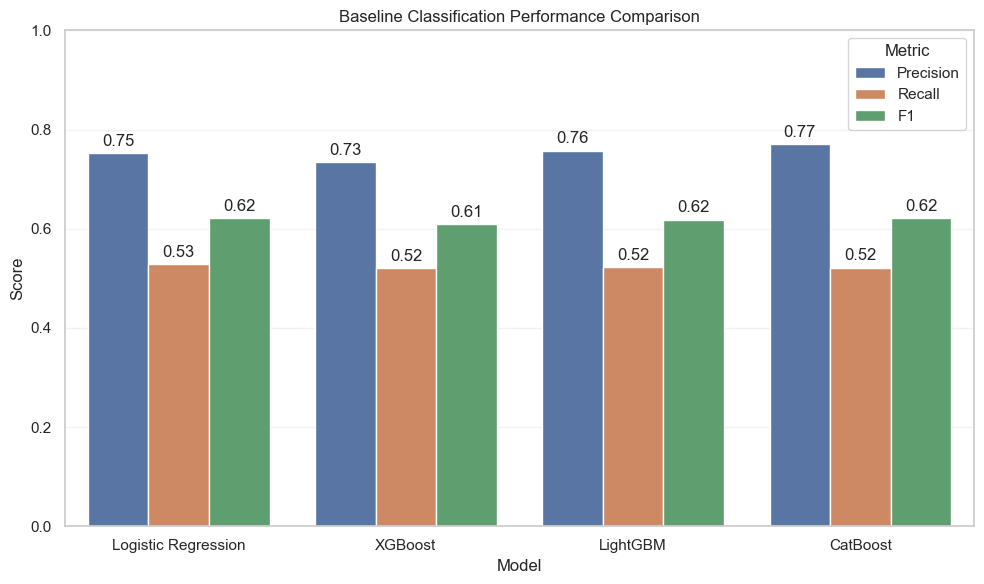

In [41]:
# Visualize Precision, Recall, and F1-score across baseline models.

classification_plot = (
    baseline_results[["Precision", "Recall", "F1"]]
    .apply(lambda column: column.str.split(" ± ").str[0].astype(float))
    .reset_index()
    .melt(
        id_vars="Model",
        var_name="Metric",
        value_name="Score"
    )
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=classification_plot,
    x="Model",
    y="Score",
    hue="Metric"
)

# Display metric values above each bar.
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=3
    )

plt.xlabel("Model")
plt.ylabel("Score")
plt.title("Baseline Classification Performance Comparison")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.25)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

### 7.6 — Class Imbalance Handling

Class imbalance is addressed through cost-sensitive learning.

During cross-validation, class weights are calculated separately within each training fold. For the final model, class weights are calculated from the full training set.

The test set is never used to determine class weights.


### 7.6.1 — Training Class Distribution


In [42]:
# Inspect the target distribution using the training set only.

class_counts = y_train.value_counts().sort_index()
class_distribution = pd.DataFrame({
    "Count": class_counts,
    "Percentage": (class_counts / len(y_train) * 100).round(2)
})

class_distribution

,Count,Percentage
Churned,,
0,32900,82.25
1,7100,17.75


### 7.6.2 — Class-Weighted Model Evaluation

The class-weighted Logistic Regression, XGBoost, and LightGBM models are evaluated using fold-specific class weights. Class weights are calculated only from each training fold to prevent validation information from influencing model training.


In [43]:
# Evaluate class-weighted Logistic Regression, XGBoost, and LightGBM
# using fold-specific class weights for strict leakage-safe validation.

weighted_results = {}

for name in ["Logistic Regression", "XGBoost", "LightGBM"]:
    fold_scores = {metric: [] for metric in scoring}

    for train_idx, val_idx in cv.split(X_train, y_train):
        X_tr = X_train.iloc[train_idx]
        X_val = X_train.iloc[val_idx]
        y_tr = y_train.iloc[train_idx]
        y_val = y_train.iloc[val_idx]

        # Calculate the positive-class weight using only the current training fold.
        neg_fold, pos_fold = np.bincount(y_tr)
        fold_scale_pos_weight = neg_fold / pos_fold

        if name == "Logistic Regression":
            estimator = LogisticRegression(
                C=1.0,
                class_weight="balanced",
                max_iter=2000,
                random_state=42
            )
        elif name == "XGBoost":
            estimator = XGBClassifier(
                objective="binary:logistic",
                eval_metric="auc",
                scale_pos_weight=fold_scale_pos_weight,
                random_state=42,
                n_jobs=1
            )
        else:
            estimator = LGBMClassifier(
                objective="binary",
                verbosity=-1,
                scale_pos_weight=fold_scale_pos_weight,
                random_state=42,
                n_jobs=1
            )

        pipe = Pipeline([
            ("preprocessor", models[name].named_steps["preprocessor"]),
            ("model", estimator)
        ])

        pipe.fit(X_tr, y_tr)

        y_prob = pipe.predict_proba(X_val)[:, 1]
        y_pred = (y_prob >= 0.5).astype(int)

        fold_scores["ROC_AUC"].append(roc_auc_score(y_val, y_prob))
        fold_scores["PR_AUC"].append(average_precision_score(y_val, y_prob))
        fold_scores["F1"].append(f1_score(y_val, y_pred, zero_division=0))
        fold_scores["Recall"].append(recall_score(y_val, y_pred, zero_division=0))
        fold_scores["Precision"].append(precision_score(y_val, y_pred, zero_division=0))

    weighted_results[name] = {
        metric: f"{np.mean(values):.4f} ± {np.std(values):.4f}"
        for metric, values in fold_scores.items()
    }

weighted_results_df = pd.DataFrame(weighted_results).T
weighted_results_df


,ROC_AUC,PR_AUC,F1,Recall,Precision
Logistic Regression,0.9004 ± 0.0036,0.7290 ± 0.0047,0.6093 ± 0.0083,0.8139 ± 0.0065,0.4869 ± 0.0093
XGBoost,0.8866 ± 0.0032,0.7068 ± 0.0043,0.6089 ± 0.0046,0.7190 ± 0.0054,0.5282 ± 0.0085
LightGBM,0.8984 ± 0.0027,0.7277 ± 0.0048,0.6116 ± 0.0084,0.7876 ± 0.0059,0.5000 ± 0.0095


### 7.7 — Hyperparameter Optimization

A compact randomized search is used to identify a strong CatBoost configuration.

Because the final system produces a churn probability and the churn class is imbalanced, configurations are selected primarily using PR-AUC, followed by ROC-AUC.

Threshold-dependent metrics such as Precision, Recall, Balanced Accuracy, and Macro F1 are retained as supporting diagnostics.

The operating threshold is optimized separately after probability calibration.


### 7.7.1 — Define Search Space

A compact search space is defined around the most influential CatBoost parameters, balancing exploration of model complexity and regularization against computational cost.


In [44]:
# Define the CatBoost hyperparameter search space.

catboost_param_space = {
    "iterations": [300, 500, 700],
    "depth": [5, 6, 7],
    "learning_rate": [0.03, 0.05],
    "l2_leaf_reg": [3, 5, 8]
}

### 7.7.2 — Randomized Configuration Sampling

A fixed random seed reproducibly samples a small number of configurations, offering broader exploration than manual selection while keeping computation practical.


In [45]:
# Randomly sample eight reproducible CatBoost configurations.

catboost_configs = list(
    ParameterSampler(
        catboost_param_space,
        n_iter=8,
        random_state=42
    )
)

catboost_configs

[{'learning_rate': 0.05, 'l2_leaf_reg': 3, 'iterations': 300, 'depth': 6},
 {'learning_rate': 0.05, 'l2_leaf_reg': 3, 'iterations': 700, 'depth': 7},
 {'learning_rate': 0.03, 'l2_leaf_reg': 3, 'iterations': 700, 'depth': 7},
 {'learning_rate': 0.03, 'l2_leaf_reg': 3, 'iterations': 700, 'depth': 5},
 {'learning_rate': 0.03, 'l2_leaf_reg': 5, 'iterations': 500, 'depth': 7},
 {'learning_rate': 0.05, 'l2_leaf_reg': 8, 'iterations': 300, 'depth': 5},
 {'learning_rate': 0.05, 'l2_leaf_reg': 8, 'iterations': 700, 'depth': 5},
 {'learning_rate': 0.03, 'l2_leaf_reg': 8, 'iterations': 700, 'depth': 7}]

### 7.7.3 — Cross-Validated Random Search

Each sampled configuration is evaluated using 5-fold stratified CV. Categorical preprocessing and class weights are computed separately within each fold to prevent validation-fold information from influencing training.


In [46]:
# Evaluate each randomly sampled configuration using stratified 5-fold cross-validation.

tuning_results = []

for params in catboost_configs:
    scores = {
        "Recall": [],
        "Precision": [],
        "ROC_AUC": [],
        "PR_AUC": [],
        "Balanced_Accuracy": [],
        "Macro_F1": []
    }

    for train_idx, val_idx in cv.split(X_train_cb, y_train):
        X_tr = X_train_cb.iloc[train_idx].copy()
        X_val = X_train_cb.iloc[val_idx].copy()
        y_tr = y_train.iloc[train_idx]
        y_val = y_train.iloc[val_idx]

        # Apply identical categorical preprocessing within the fold.
        X_tr[catboost_features] = X_tr[catboost_features].fillna("__MISSING__").astype(str)
        X_val[catboost_features] = X_val[catboost_features].fillna("__MISSING__").astype(str)

        cat_feature_indices = [X_tr.columns.get_loc(col) for col in catboost_features]

        # Calculate class weights using only the fold's training data.
        fold_classes = np.array([0, 1])
        fold_weights = compute_class_weight(
            class_weight="balanced",
            classes=fold_classes,
            y=y_tr
        )

        fold_class_weights = dict(zip(fold_classes, fold_weights))

        # Train the class-weighted CatBoost model.
        model = CatBoostClassifier(
            **params,
            loss_function="Logloss",
            eval_metric="AUC",
            class_weights=fold_class_weights,
            random_seed=42,
            verbose=0,
            thread_count=4
        )

        model.fit(X_tr, y_tr, cat_features=cat_feature_indices)

        # Generate validation probabilities and threshold-based predictions.
        y_prob = model.predict_proba(X_val)[:, 1]
        y_pred = (y_prob >= 0.5).astype(int)

        scores["Recall"].append(recall_score(y_val, y_pred))
        scores["Precision"].append(precision_score(y_val, y_pred))
        scores["ROC_AUC"].append(roc_auc_score(y_val, y_prob))
        scores["PR_AUC"].append(average_precision_score(y_val, y_prob))
        scores["Balanced_Accuracy"].append(balanced_accuracy_score(y_val, y_pred))
        scores["Macro_F1"].append(f1_score(y_val, y_pred, average="macro"))

    tuning_results.append({
        **params,
        **{metric: np.mean(values) for metric, values in scores.items()}
    })

catboost_tuning_results = pd.DataFrame(tuning_results)


### 7.7.4 — Rank Random Search Results


In [47]:
# Rank configurations primarily by probability-ranking quality.
# PR-AUC is the primary selection metric, followed by ROC-AUC.

catboost_tuning_results = (
    catboost_tuning_results
    .sort_values(
        [
            "PR_AUC",
            "ROC_AUC",
            "Precision",
            "Recall",
            "Balanced_Accuracy",
            "Macro_F1"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)

catboost_tuning_results     

,learning_rate,l2_leaf_reg,iterations,depth,Recall,Precision,ROC_AUC,PR_AUC,Balanced_Accuracy,Macro_F1
0,0.03,3,700,5,0.80,0.50,0.90,0.74,0.81,0.75
1,0.05,3,300,6,0.80,0.50,0.90,0.74,0.81,0.75
2,0.03,8,700,7,0.79,0.51,0.90,0.74,0.81,0.76
3,0.05,8,300,5,0.80,0.50,0.90,0.74,0.81,0.75
4,0.03,5,500,7,0.79,0.51,0.90,0.74,0.81,0.75
5,0.03,3,700,7,0.78,0.52,0.90,0.73,0.81,0.76
6,0.05,8,700,5,0.79,0.50,0.90,0.73,0.81,0.75
7,0.05,3,700,7,0.76,0.53,0.90,0.73,0.81,0.76




Configurations are ranked primarily by probability-ranking quality.

PR-AUC is the primary selection metric because the final system produces
churn probabilities and the churn class is imbalanced.

ROC-AUC is used as the secondary discrimination metric, while
threshold-dependent metrics are retained as supporting diagnostics.

The classification threshold is optimized separately after probability
calibration and is not used for hyperparameter selection.

### 7.7.5 — Select Best Configuration

The highest-ranked configuration is carried forward for out-of-fold prediction, probability calibration, and threshold optimization.


In [48]:
# Extract the best CatBoost configuration for the next stage.

best_catboost_params = catboost_tuning_results.loc[0, [
    "iterations",
    "depth",
    "learning_rate",
    "l2_leaf_reg"
]].to_dict()

best_catboost_params["iterations"] = int(best_catboost_params["iterations"])
best_catboost_params["depth"] = int(best_catboost_params["depth"])
best_catboost_params["l2_leaf_reg"] = int(best_catboost_params["l2_leaf_reg"])

best_catboost_params

{'iterations': 700, 'depth': 5, 'learning_rate': 0.03, 'l2_leaf_reg': 3}

### 7.8 — Tuned CatBoost Out-of-Fold Validation

The selected CatBoost configuration is evaluated with stratified CV to generate out-of-fold (OOF) probability predictions, produced only from validation folds, for later calibration and threshold optimization without touching the test set.


### 7.8.1 — Generate OOF Predictions


In [49]:
# Generate out-of-fold probabilities using fold-specific class weights.

oof_prob = np.zeros(len(X_train_cb))

for train_idx, val_idx in cv.split(X_train_cb, y_train):
    X_tr = X_train_cb.iloc[train_idx].copy()
    X_val = X_train_cb.iloc[val_idx].copy()
    y_tr = y_train.iloc[train_idx]

    # Apply the same categorical preprocessing used during tuning.
    X_tr[catboost_features] = X_tr[catboost_features].fillna("__MISSING__").astype(str)
    X_val[catboost_features] = X_val[catboost_features].fillna("__MISSING__").astype(str)

    cat_feature_indices = [X_tr.columns.get_loc(col) for col in catboost_features]

    # Calculate class weights using only the current training fold.
    fold_weights = compute_class_weight(
        class_weight="balanced",
        classes=np.array([0, 1]),
        y=y_tr
    )
    fold_class_weights = dict(zip([0, 1], fold_weights))

    # Train the tuned class-weighted CatBoost model.
    model = CatBoostClassifier(
        **best_catboost_params,
        loss_function="Logloss",
        eval_metric="AUC",
        class_weights=fold_class_weights,
        random_seed=42,
        verbose=0,
        thread_count=4
    )

    model.fit(X_tr, y_tr, cat_features=cat_feature_indices)

    # Store predictions only for the validation fold.
    oof_prob[val_idx] = model.predict_proba(X_val)[:, 1]

### 7.9 — Probability Calibration

Isotonic regression is used to calibrate the CatBoost churn probabilities.

The calibrator is fitted using one portion of the training-side OOF predictions and evaluated on a separate held-out OOF portion. The test set remains untouched until final evaluation.

Brier Score is used to assess probability reliability before and after calibration.


In [50]:
# Split OOF probabilities into calibration and validation portions.

oof_cal_prob, oof_val_prob, y_cal, y_val = train_test_split(
    oof_prob,
    y_train,
    test_size=0.30,
    stratify=y_train,
    random_state=42
)

# Fit isotonic calibration using only the calibration portion.
calibrator = IsotonicRegression(out_of_bounds="clip")
calibrator.fit(oof_cal_prob, y_cal)

# Generate calibrated probabilities on the held-out OOF validation portion.
calibrated_oof_prob = calibrator.predict(oof_val_prob)

# Compare probability reliability before and after calibration.
calibration_results = pd.DataFrame({
    "Metric": ["Brier Score"],
    "Before Calibration": [
        brier_score_loss(y_val, oof_val_prob)
    ],
    "After Calibration": [
        brier_score_loss(y_val, calibrated_oof_prob)
    ]
})

calibration_results

,Metric,Before Calibration,After Calibration
0,Brier Score,0.12,0.08


### 7.10 — Calibration Curve

The calibration curve provides a visual assessment of probability reliability
by comparing predicted churn probabilities with the observed churn rate.

The diagonal line represents perfect calibration, where predicted probabilities
match observed outcomes.

The curves before and after isotonic calibration are compared to assess whether
calibration improves the alignment between predicted probabilities and observed
churn frequencies.

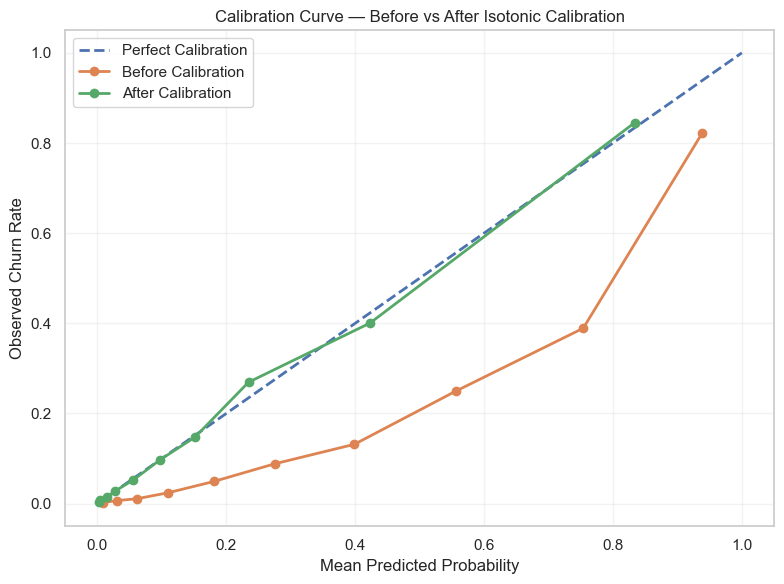

In [51]:
# Calibration curve utility for evaluating probability reliability.
from sklearn.calibration import calibration_curve

# Plot calibration curves before and after isotonic calibration.

prob_true_before, prob_pred_before = calibration_curve(
    y_val,
    oof_val_prob,
    n_bins=10,
    strategy="quantile"
)

prob_true_after, prob_pred_after = calibration_curve(
    y_val,
    calibrated_oof_prob,
    n_bins=10,
    strategy="quantile"
)

plt.figure(figsize=(8, 6))

plt.plot(
    [0, 1], [0, 1],
    linestyle="--",
    linewidth=2,
    label="Perfect Calibration"
)

plt.plot(
    prob_pred_before,
    prob_true_before,
    marker="o",
    linewidth=2,
    label="Before Calibration"
)

plt.plot(
    prob_pred_after,
    prob_true_after,
    marker="o",
    linewidth=2,
    label="After Calibration"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Churn Rate")
plt.title("Calibration Curve — Before vs After Isotonic Calibration")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

### 7.11 — Threshold Optimization

The classification threshold is optimized using calibrated OOF probabilities.

A minimum Precision constraint is applied, and among thresholds satisfying that constraint, the threshold with the highest Recall is selected. The test set remains untouched during threshold selection.


In [52]:
# Evaluate threshold-dependent classification metrics on calibrated OOF probabilities.

threshold_results = []

for threshold in np.arange(0.10, 0.91, 0.05):
    threshold = round(float(threshold), 2)
    y_pred = (calibrated_oof_prob >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Recall": recall_score(y_val, y_pred, zero_division=0),
        "Precision": precision_score(y_val, y_pred, zero_division=0),
        "F1": f1_score(y_val, y_pred, zero_division=0),
        "Balanced_Accuracy": balanced_accuracy_score(y_val, y_pred),
        "Macro_F1": f1_score(y_val, y_pred, average="macro")
    })

threshold_results = pd.DataFrame(threshold_results)

threshold_results

,Threshold,Recall,Precision,F1,Balanced_Accuracy,Macro_F1
0,0.10,0.93,0.36,0.52,0.79,0.65
1,0.15,0.85,0.46,0.60,0.82,0.73
2,0.20,0.82,0.50,0.62,0.82,0.75
3,0.25,0.72,0.58,0.64,0.80,0.78
4,0.30,0.66,0.62,0.64,0.79,0.78
5,0.35,0.60,0.68,0.64,0.77,0.78
6,0.40,0.58,0.72,0.64,0.77,0.79
7,0.45,0.53,0.75,0.62,0.75,0.78
8,0.50,0.52,0.77,0.62,0.74,0.78
9,0.55,0.44,0.84,0.58,0.71,0.76


### 7.11.1 — Select the Operating Threshold

A minimum Precision of 0.60 is used as the operating constraint — at least 60% of flagged high-risk customers are expected to be actual churners. Among thresholds meeting this constraint, the one with the highest Recall is selected, using Precision as the tie-breaker.


In [53]:
# Select the threshold with maximum Recall subject to the minimum Precision constraint.

min_precision = 0.60

eligible_thresholds = threshold_results[
    threshold_results["Precision"] >= min_precision
].copy()

if eligible_thresholds.empty:
    raise ValueError(
        f"No evaluated threshold achieved the required minimum Precision of "
        f"{min_precision:.0%}. Review the precision constraint or threshold grid."
    )

best_threshold = (
    eligible_thresholds
    .sort_values(
        ["Recall", "Precision"],
        ascending=[False, False]
    )
    .iloc[0]["Threshold"]
)

print(f"Selected operating threshold: {best_threshold:.2f}")

Selected operating threshold: 0.30


### 7.11.2 — Review Threshold Trade-Off


In [54]:
# Review thresholds that satisfy the minimum Precision requirement.

eligible_thresholds.sort_values(
    ["Recall", "Precision"],
    ascending=[False, False]
)

,Threshold,Recall,Precision,F1,Balanced_Accuracy,Macro_F1
4,0.30,0.66,0.62,0.64,0.79,0.78
5,0.35,0.60,0.68,0.64,0.77,0.78
6,0.40,0.58,0.72,0.64,0.77,0.79
7,0.45,0.53,0.75,0.62,0.75,0.78
8,0.50,0.52,0.77,0.62,0.74,0.78
9,0.55,0.44,0.84,0.58,0.71,0.76
10,0.60,0.41,0.87,0.56,0.70,0.75
11,0.65,0.39,0.89,0.54,0.69,0.74
12,0.70,0.37,0.90,0.52,0.68,0.73
13,0.75,0.34,0.92,0.50,0.67,0.71


### 7.12 — Final Test Evaluation

The selected CatBoost configuration is retrained on the full training set and evaluated once on the untouched test set, using the calibrated probabilities and operating threshold selected exclusively from training-side OOF predictions.


### 7.12.1 — Train Final CatBoost Model

The selected configuration is retrained on the full training dataset. Class weights are calculated from training data only; the test set remains untouched.


In [55]:
# Prepare the full training data and calculate training-only class weights.

X_train_final = X_train_cb.copy()

X_train_final[catboost_features] = (
    X_train_final[catboost_features]
    .fillna("__MISSING__")
    .astype(str)
)

final_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=y_train
)

final_class_weights = dict(zip([0, 1], final_weights))

cat_feature_indices = [
    X_train_final.columns.get_loc(col)
    for col in catboost_features
]

# Train the final class-weighted CatBoost model using the selected configuration.

final_catboost_model = CatBoostClassifier(
    **best_catboost_params,
    loss_function="Logloss",
    eval_metric="AUC",
    class_weights=final_class_weights,
    random_seed=42,
    verbose=0,
    thread_count=4
)

final_catboost_model.fit(
    X_train_final,
    y_train,
    cat_features=cat_feature_indices
)


CatBoostClassifier(class_weights={0: np.float64(0.60790273556231), 1: np.float64(2.816901408450704)}, depth=5, eval_metric='AUC', iterations=700, l2_leaf_reg=3, learning_rate=0.03, loss_function='Logloss', random_seed=42, thread_count=4, verbose=0)

### 7.12.2 — Generate Test Probabilities

The final model generates churn probabilities for the untouched test set, using the same categorical representation applied during training.


In [56]:
# Prepare the untouched test set using the same categorical representation as training.

X_test_final = X_test.copy()

X_test_final[catboost_features] = (
    X_test_final[catboost_features]
    .fillna("__MISSING__")
    .astype(str)
)

# Generate raw churn probabilities for the test set.
test_prob = final_catboost_model.predict_proba(X_test_final)[:, 1]

### 7.12.3 — Apply Calibration and Operating Threshold

Final model probabilities are passed through the calibration model fitted on training-side OOF predictions, then the previously selected operating threshold is applied with no further tuning on the test set.


In [57]:
# Calibrate test probabilities and apply the previously selected operating threshold.

calibrated_test_prob = calibrator.predict(test_prob)
y_test_pred = (calibrated_test_prob >= best_threshold).astype(int)

print(f"Operating threshold: {best_threshold:.2f}")

Operating threshold: 0.30


### 7.12.4 — Final Test Performance

The final model is evaluated on the untouched test set using both probability-based and threshold-based metrics.

PR-AUC and ROC-AUC assess discrimination, Brier Score assesses probability reliability, while Recall, Precision, F1, Balanced Accuracy, and Macro F1 evaluate the selected operating threshold.


In [58]:
# Calculate final test-set performance using the selected operating threshold.

final_test_metrics = {
    "ROC_AUC": roc_auc_score(y_test, calibrated_test_prob),
    "PR_AUC": average_precision_score(y_test, calibrated_test_prob),
    "Brier_Score": brier_score_loss(y_test, calibrated_test_prob),
    "Recall": recall_score(y_test, y_test_pred, zero_division=0),
    "Precision": precision_score(y_test, y_test_pred, zero_division=0),
    "F1": f1_score(y_test, y_test_pred, zero_division=0),
    "Balanced_Accuracy": balanced_accuracy_score(y_test, y_test_pred),
    "Macro_F1": f1_score(y_test, y_test_pred, average="macro")
}

final_test_metrics_df = pd.DataFrame({
    "Metric": list(final_test_metrics.keys()),
    "Score": list(final_test_metrics.values())
})

final_test_metrics_df

,Metric,Score
0,ROC_AUC,0.90
1,PR_AUC,0.71
2,Brier_Score,0.08
3,Recall,0.67
4,Precision,0.62
5,F1,0.64
6,Balanced_Accuracy,0.79
7,Macro_F1,0.78


### 7.12.5 — Final Tuned CatBoost Classification Performance

The final tuned CatBoost model is evaluated on the untouched test set using classification metrics to summarize its ability to identify churn customers at the selected operating threshold.

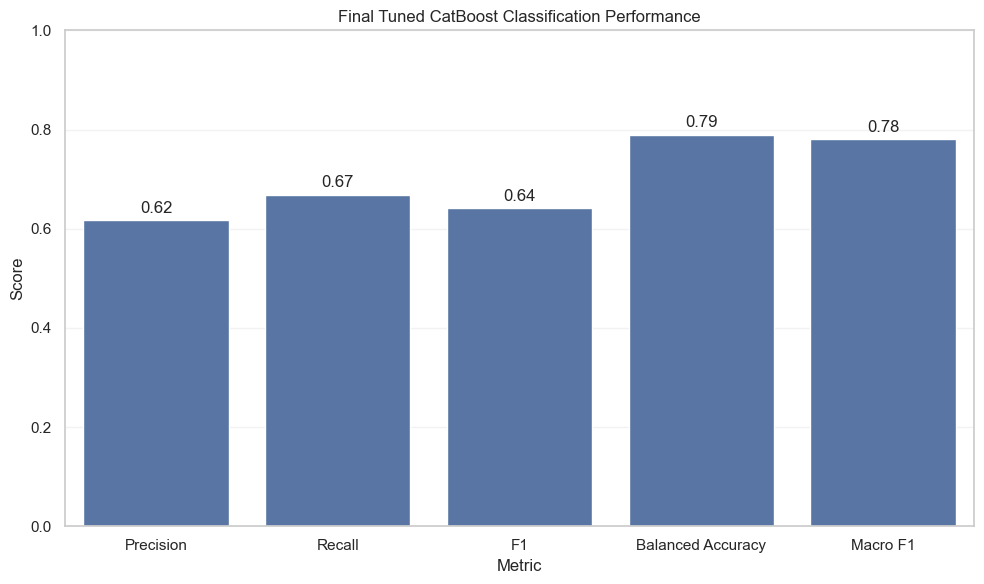

In [59]:
# Visualize final tuned CatBoost classification performance on the untouched test set.

final_classification_metrics = pd.DataFrame({
    "Metric": [
        "Precision",
        "Recall",
        "F1",
        "Balanced Accuracy",
        "Macro F1"
    ],
    "Score": [
        precision_score(y_test, y_test_pred, zero_division=0),
        recall_score(y_test, y_test_pred, zero_division=0),
        f1_score(y_test, y_test_pred, zero_division=0),
        balanced_accuracy_score(y_test, y_test_pred),
        f1_score(y_test, y_test_pred, average="macro", zero_division=0)
    ]
})

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=final_classification_metrics,
    x="Metric",
    y="Score"
)

# Display metric values above each bar.
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=3
    )

plt.xlabel("Metric")
plt.ylabel("Score")
plt.title("Final Tuned CatBoost Classification Performance")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

### 7.12.5 — Confusion Matrix

The confusion matrix visualizes final classification results at the selected operating threshold, showing correctly and incorrectly classified churn and non-churn customers.


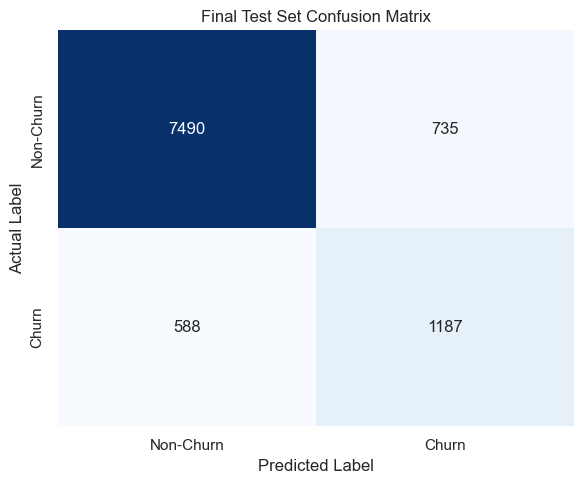

In [60]:
# Plot the final test-set confusion matrix.

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Non-Churn", "Churn"],
    yticklabels=["Non-Churn", "Churn"]
)

plt.title("Final Test Set Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

#### Key Insights

The model correctly identifies 1,187 churned customers while missing 588 actual churn cases.
It generates 735 false churn predictions, indicating some customers may receive unnecessary retention attention.
Overall, the confusion matrix shows a reasonable balance between identifying churners and limiting false-positive predictions.

### 7.12.6 — ROC-AUC and PR-AUC Curves

The ROC-AUC and Precision-Recall curves evaluate the final CatBoost model across different classification thresholds. ROC-AUC measures the model's ability to distinguish churners from non-churners, while PR-AUC provides a more informative view of performance for the imbalanced churn class.

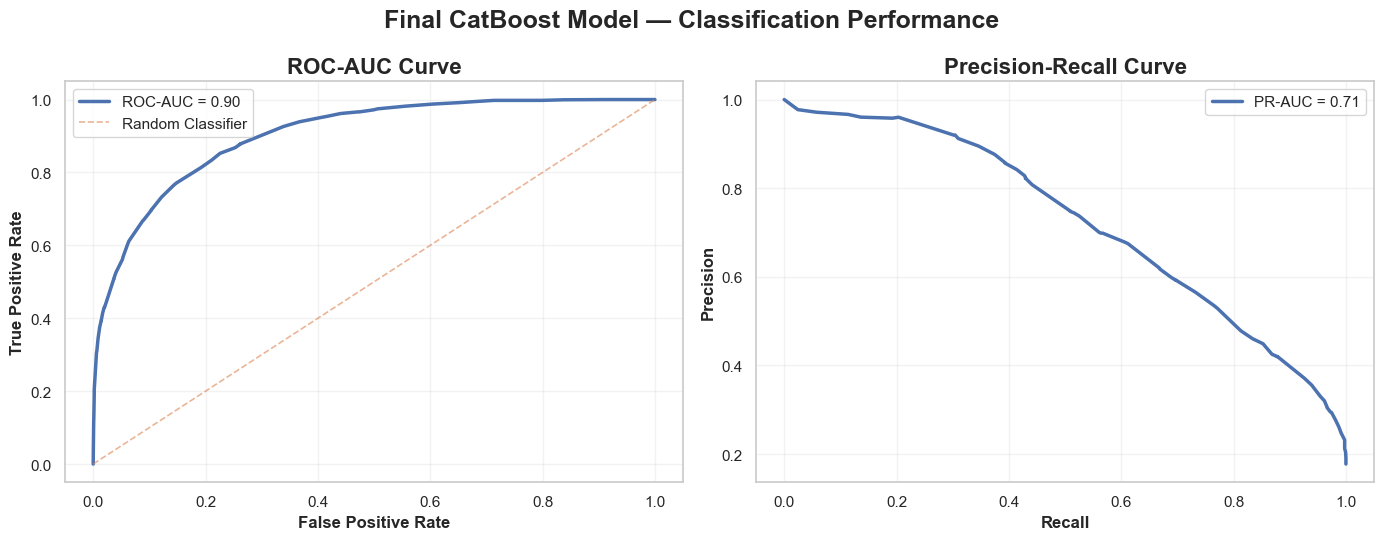

In [61]:
# Plot ROC-AUC and PR-AUC curves on the final test set.

fpr, tpr, _ = roc_curve(y_test, calibrated_test_prob)
precision, recall, _ = precision_recall_curve(y_test, calibrated_test_prob)
roc_auc = roc_auc_score(y_test, calibrated_test_prob)
pr_auc = average_precision_score(y_test, calibrated_test_prob)

fig, ax = plt.subplots(1, 2, figsize=(14, 5.5))

# ROC-AUC curve
ax[0].plot(fpr, tpr, linewidth=2.5, label=f"ROC-AUC = {roc_auc:.2f}")
ax[0].plot([0, 1], [0, 1], "--", linewidth=1.2, alpha=0.6, label="Random Classifier")
ax[0].set_title("ROC-AUC Curve", fontsize=16, fontweight="bold")
ax[0].set_xlabel("False Positive Rate", fontweight="bold")
ax[0].set_ylabel("True Positive Rate", fontweight="bold")
ax[0].legend()
ax[0].grid(alpha=0.25)

# Precision-Recall curve
ax[1].plot(recall, precision, linewidth=2.5, label=f"PR-AUC = {pr_auc:.2f}")
ax[1].set_title("Precision-Recall Curve", fontsize=16, fontweight="bold")
ax[1].set_xlabel("Recall", fontweight="bold")
ax[1].set_ylabel("Precision", fontweight="bold")
ax[1].legend()
ax[1].grid(alpha=0.25)

fig.suptitle(
    "Final CatBoost Model — Classification Performance",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

#### ROC-AUC and PR-AUC Interpretation

- The model achieves strong discrimination with a ROC-AUC of **0.90**, indicating effective separation between churn and non-churn customers.
- The PR-AUC of **0.71** reflects useful precision–recall performance despite the imbalanced churn distribution.
- Precision decreases as recall increases, highlighting the expected trade-off between identifying more churners and generating more false-positive predictions.

## Phase 8 — Model Interpretation (SHAP Explainability)

SHAP is used to interpret the final CatBoost model by identifying the features that contribute most strongly to churn predictions, providing model transparency and translating predictions into actionable customer-risk drivers.


### 8.1 — SHAP Feature Importance Plot

Global SHAP importance identifies the features with the greatest influence on the model's churn predictions, computed on a representative training sample to keep computation efficient.


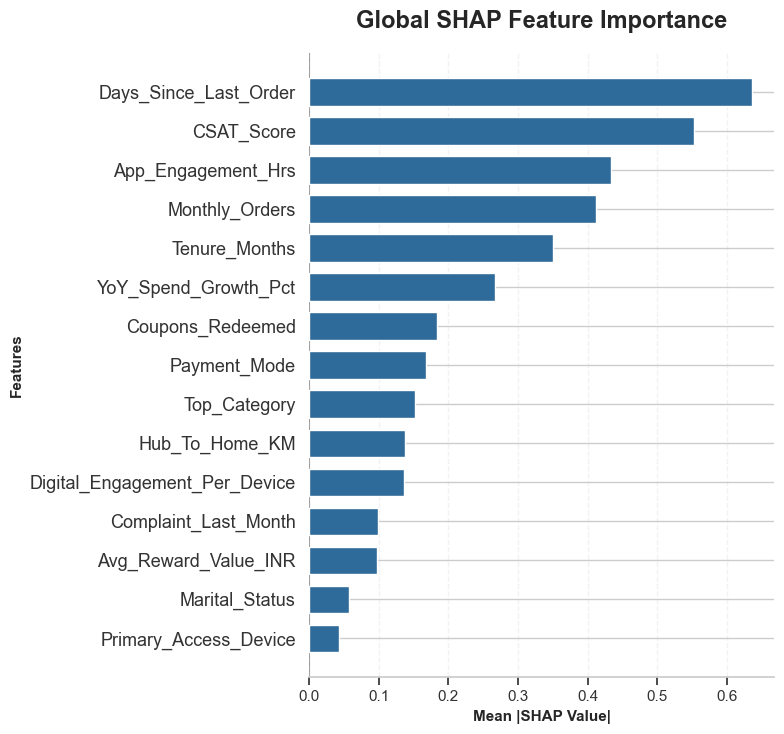

In [62]:
# Calculate and visualize global SHAP feature importance.

X_shap = X_train_final.sample(min(2000, len(X_train_final)), random_state=42)

explainer = shap.TreeExplainer(final_catboost_model)
shap_values = explainer.shap_values(X_shap)

plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values,
    X_shap,
    plot_type="bar",
    max_display=15,
    color="#2F6B9A",
    show=False
)

plt.title(
    "Global SHAP Feature Importance",
    fontsize=17,
    fontweight="bold",
    pad=18
)
plt.xlabel("Mean |SHAP Value|", fontsize=11, fontweight="bold")
plt.ylabel("Features", fontsize=11, fontweight="bold")
plt.grid(axis="x", linestyle="--", alpha=0.25)
plt.tight_layout()
plt.show()

#### Key Highlights — Global SHAP Feature Importance

- **Days_Since_Last_Order** is the most influential feature, showing that customer recency has the strongest overall contribution to the model's predictions.
- **CSAT_Score** and **Monthly_Orders** are the next most influential features, highlighting the importance of customer satisfaction and purchasing behaviour.
- **App_Engagement_Hrs** and **Tenure_Months** also make substantial contributions to the model's predictions.
- **YoY_Spend_Growth_Pct** and **Coupons_Redeemed** provide moderate predictive contribution.
- The engineered feature **Digital_Engagement_Per_Device** contributes meaningful predictive information and appears among the more influential features.
- **Payment_Mode, Top_Category, Hub_To_Home_KM, Complaint_Last_Month, and Avg_Reward_Value_INR** have smaller but measurable contributions.
- **Marital_Status** and **Primary_Access_Device** have the lowest average SHAP importance among the displayed features.
- Overall, the model is influenced most strongly by **customer recency, satisfaction, purchasing activity, engagement, and tenure**.
- These results describe **model behaviour, not causal relationships**. Mean absolute SHAP values indicate feature influence magnitude but do not show whether a feature increases or decreases churn risk.


### 8.2 — SHAP Summary Plot

The SHAP summary plot shows how individual feature values influence churn predictions, capturing both the magnitude and direction of each feature's contribution.


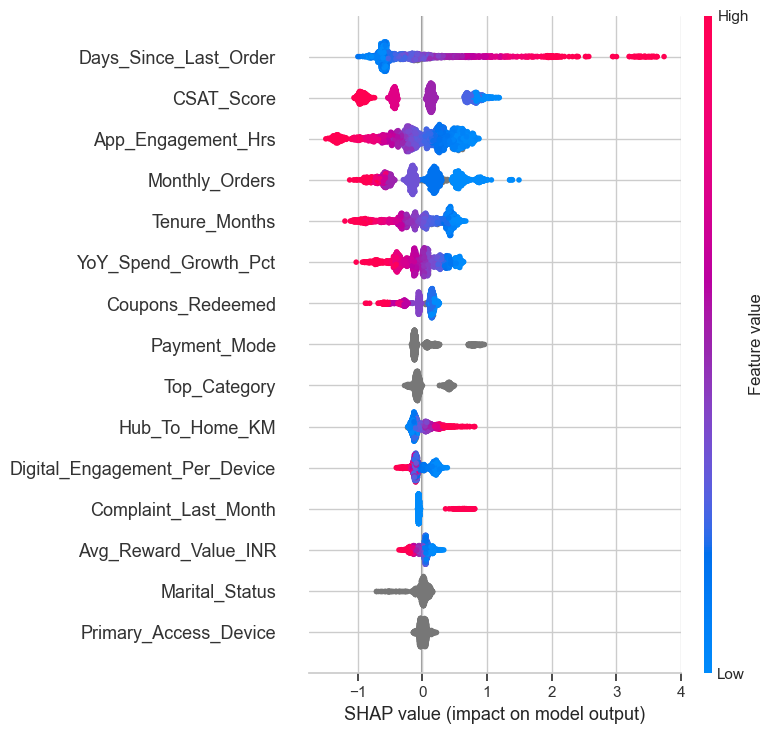

In [63]:
# Visualize the direction and magnitude of feature contributions.

shap.summary_plot(
    shap_values,
    X_shap,
    max_display=15
)

#### Key Insights — SHAP Summary Plot

The SHAP summary plot highlights how feature values influence the model's churn predictions.

- **Customer recency is the strongest directional signal:** Higher `Days_Since_Last_Order` values generally push predictions toward higher churn risk.
- **Customer satisfaction matters strongly:** Lower `CSAT_Score` values tend to increase the model's predicted churn risk, while higher scores generally reduce it.
- **Purchasing behaviour is important:** Lower `Monthly_Orders` values generally push predictions toward churn, while higher order frequency tends to reduce predicted churn risk.
- **Digital engagement shows a clear pattern:** Lower `App_Engagement_Hrs` values generally contribute toward higher churn predictions.
- **Customer tenure contributes meaningfully:** Shorter `Tenure_Months` generally pushes predictions toward higher churn risk, while longer tenure tends to reduce it.
- **Spending behaviour provides additional signal:** Lower `YoY_Spend_Growth_Pct` values generally contribute toward higher churn predictions.
- **Customer experience and rewards also contribute:** Recent complaints and lower reward values tend to push predictions toward higher churn risk.
- **Several categorical features have smaller or more varied effects:** `Payment_Mode`, `Top_Category`, `Marital_Status`, and `Primary_Access_Device` show comparatively lower overall influence.
- Overall, the model's predictions are primarily shaped by **recency, satisfaction, purchasing activity, engagement, tenure, spending behaviour, and customer experience**.
- These patterns represent **model behaviour, not causal relationships**, and should be interpreted as predictive associations rather than direct business causation.


## Phase 9 — Final Results & Conclusion

Summarizes the final CatBoost model's test-set performance, configuration, and overall project conclusion.


### 9.1 — Final Performance Summary

The final CatBoost model is evaluated once on the untouched test set.

PR-AUC and ROC-AUC assess probability-based discrimination, Brier Score assesses probability reliability, and Recall, Precision, F1, Balanced Accuracy, and Macro F1 evaluate the selected operating threshold.

The calibrated churn probability is the primary model output, while the operating threshold provides an optional binary churn decision.


In [64]:
# Display the final test-set performance metrics.

final_test_metrics_df

,Metric,Score
0,ROC_AUC,0.90
1,PR_AUC,0.71
2,Brier_Score,0.08
3,Recall,0.67
4,Precision,0.62
5,F1,0.64
6,Balanced_Accuracy,0.79
7,Macro_F1,0.78


### 9.2 — Final Model Configuration

The final system uses the selected CatBoost configuration with class weighting, probability calibration, and a training-selected operating threshold.

Hyperparameters, class weights, calibration parameters, and the operating threshold are determined exclusively from training-side data. The test set is used only for the final performance evaluation.


In [65]:
# Display the final model configuration.

print("Best CatBoost parameters:", best_catboost_params)
print(f"Operating threshold: {best_threshold:.2f}")

Best CatBoost parameters: {'iterations': 700, 'depth': 5, 'learning_rate': 0.03, 'l2_leaf_reg': 3}
Operating threshold: 0.30


### 9.3 — Model Artifact Export

The final CatBoost model, the isotonic calibrator, and the operating threshold are packaged into a single joblib artifact so the deployed API can reproduce the notebook's inference pipeline without retraining.

The artifact contains only the objects fitted and selected from training-side data in Sections 7.9 to 7.12; the test set is not used to produce it.

In [66]:
import joblib

joblib.dump(
    {
        "model": final_catboost_model,
        "calibrator": calibrator,
        "threshold": best_threshold,
    },
    "../model/churn_model.pkl",
)

['../model/churn_model.pkl']

### 9.4 — Conclusion

The final CatBoost model provides an end-to-end churn probability prediction system evaluated on an untouched test set.

The workflow combines leakage-safe preprocessing, class-imbalance handling, hyperparameter optimization, out-of-fold probability calibration, operating-threshold selection, final test evaluation, and SHAP-based model interpretation.

The calibrated churn probability is the primary model output, while the selected operating threshold provides an optional binary churn decision.

Final performance should be interpreted from the metrics reported in Section 9.1 rather than from manually stated values.
